# Explorative Datenanalyse – Santander Customer Transaction Prediction

Dieses Notebook ist die **fachlich sortierte Endfassung der EDA**. Es trennt technische
Datenprüfung, univariate Gruppenunterschiede, Abhängigkeitsanalysen, Dimensionsreduktion und
eine erste überwachte Referenz klar voneinander.

**Quelle:** OpenML-Datensatz `45566`  
**Lokale Datei:** `../data/santander_customer_transaction_prediction.csv`  
**Zielvariable:** `target`

## Methodischer Rahmen

Die Analyse trennt drei Ebenen:

1. **Deskriptive EDA auf dem vollständigen Datensatz:** Datenqualität, Verteilungen,
   Effektgrößen, Korrelationen und explorative Projektionen beschreiben die vorhandenen Daten.
2. **Sensitivitäts- und Stabilitätsanalysen:** 1:1-Teilstichproben, mehrere Seeds und
   Bootstrap-Resamples prüfen, ob Befunde stark von einzelnen Stichproben abhängen.
3. **Prädiktive Evaluation:** Sobald Modellgüte auf einem Testset berichtet wird, werden
   Split und Vorverarbeitung leakage-frei durchgeführt. Label-informierte Featureselektion
   gehört später innerhalb von Trainingsdaten bzw. Cross-Validation-Folds.

**Leseregel:** Statistische Signifikanz ist nicht gleich praktische Relevanz.
PCA/t-SNE und Clustering sind explorative Hilfsmittel und kein Nachweis für oder gegen
Vorhersagbarkeit.


## 1. Datenbasis und technische Prüfung

### 1.1 Datenquelle, Imports und reproduzierbares Setup


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from scipy.stats import ttest_ind

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    normalized_mutual_info_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

RANDOM_STATE = 42
DATA_PATH = Path("../data/santander_customer_transaction_prediction.csv")
ASSET_PATH = Path("assets")
ASSET_PATH.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Datensatz nicht gefunden: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, low_memory=False)

TARGET = "target"
if TARGET not in df.columns:
    raise KeyError(f"Erwartete Zielvariable fehlt: {TARGET}")

feature_columns = [column for column in df.columns if column != TARGET]
X = df[feature_columns].copy()
y = df[TARGET].copy()

assert TARGET not in X.columns
assert len(feature_columns) == 200

sns.set_theme(style="whitegrid", context="notebook")

print(f"Datei: {DATA_PATH.resolve()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Python: {sys.version.split()[0]}")
print("Featurematrix X:", X.shape)
print("Label y:", y.shape, y.dtype)


Datei: C:\Users\Cypsa\Desktop\UNI\UNI JLU DS\ADA_Project\Cyp\data\santander_customer_transaction_prediction.csv
pandas: 2.2.3
NumPy: 2.0.0
Python: 3.12.3
Featurematrix X: (200000, 200)
Label y: (200000,) bool


### 1.2 Form, Größe, Spalten und Datentypen

Zuerst wird geprüft, ob die geladene Datei dem erwarteten Aufbau entspricht. Diese
Bestandsaufnahme ist Voraussetzung für alle späteren Transformationen.


In [2]:
n_rows, n_cols = df.shape
memory_bytes = df.memory_usage(index=True, deep=True).sum()

size_summary = pd.Series({
    "Rows": n_rows,
    "Columns": n_cols,
    "Speicherbedarf im DataFrame (MiB)": memory_bytes / 1024**2,
    "CSV-Dateigröße (MiB)": DATA_PATH.stat().st_size / 1024**2,
    "Durchschnittlicher Speicherbedarf je Row (KiB)": memory_bytes / n_rows / 1024,
}).round(3)
display(size_summary.to_frame("Wert"))

column_overview = pd.DataFrame({
    "Spaltenname": df.columns,
    "Datentyp": df.dtypes.astype(str).to_numpy(),
    "Anzahl eindeutiger Werte": [df[col].nunique(dropna=False) for col in df.columns],
    "Fehlende Werte": [df[col].isna().sum() for col in df.columns],
})

print("\nAnzahl Spalten je Datentyp:")
display(df.dtypes.astype(str).value_counts().rename_axis("Datentyp").to_frame("Anzahl Spalten"))
display(column_overview)
display(df.head())


,Wert
Rows,200000.000
Columns,201.000
Speicherbedarf im DataFrame (MiB),305.367
CSV-Dateigröße (MiB),292.016
Durchschnittlicher Speicherbedarf je Row (KiB),1.563



Anzahl Spalten je Datentyp:


,Anzahl Spalten
Datentyp,
float64,200
bool,1


,Spaltenname,Datentyp,Anzahl eindeutiger Werte,Fehlende Werte
0,var_0,float64,94672,0
1,var_1,float64,108932,0
2,var_2,float64,86555,0
3,var_3,float64,74597,0
4,var_4,float64,63515,0
...,...,...,...,...
196,var_196,float64,125560,0
197,var_197,float64,40537,0
198,var_198,float64,94153,0
199,var_199,float64,149430,0


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,...,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914,False
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,...,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518,False
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,...,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965,False
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,...,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996,False
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,...,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104,False


### 1.3 Datenqualität: Missing Values, Duplikate und nicht-finite Werte

Fehlende Werte, vollständige Duplikate, doppelte Featurevektoren und nicht-finite
Featurewerte werden getrennt geprüft. Die Prüfung verändert die Rohdaten nicht.


In [3]:
missing_by_column = (
    df.isna().sum()
      .rename("Anzahl fehlender Werte")
      .to_frame()
      .assign(**{
          "Anteil fehlender Werte (%)":
          lambda frame: frame["Anzahl fehlender Werte"] / len(df) * 100
      })
      .sort_values("Anzahl fehlender Werte", ascending=False)
)

duplicate_full_rows = int(df.duplicated().sum())
duplicate_feature_rows = int(X.duplicated().sum())
nonfinite_feature_cells = int((~np.isfinite(X.to_numpy(dtype=float))).sum())

quality_summary = pd.Series({
    "Fehlende Zellen insgesamt": int(df.isna().sum().sum()),
    "Rows mit mindestens einem fehlenden Wert": int(df.isna().any(axis=1).sum()),
    "Spalten mit mindestens einem fehlenden Wert":
        int((missing_by_column["Anzahl fehlender Werte"] > 0).sum()),
    "Vollständig doppelte Zeilen": duplicate_full_rows,
    "Doppelte Featurevektoren (Label ignoriert)": duplicate_feature_rows,
    "Nicht-finite Featurezellen (±inf/NaN)": nonfinite_feature_cells,
})
display(quality_summary.to_frame("Anzahl"))

if (missing_by_column["Anzahl fehlender Werte"] > 0).any():
    display(missing_by_column[missing_by_column["Anzahl fehlender Werte"] > 0])


,Anzahl
Fehlende Zellen insgesamt,0
Rows mit mindestens einem fehlenden Wert,0
Spalten mit mindestens einem fehlenden Wert,0
Vollständig doppelte Zeilen,0
Doppelte Featurevektoren (Label ignoriert),0
Nicht-finite Featurezellen (±inf/NaN),0


### 1.4 Zielvariable und Klassenimbalance

Die Klassenverteilung wird früh bestimmt, weil sie die Interpretation von Signifikanztests,
Stichproben und späteren Modellmetriken beeinflusst. Ein einziges beschriftetes Balkendiagramm
ist hier informativer als mehrere redundante Darstellungen.


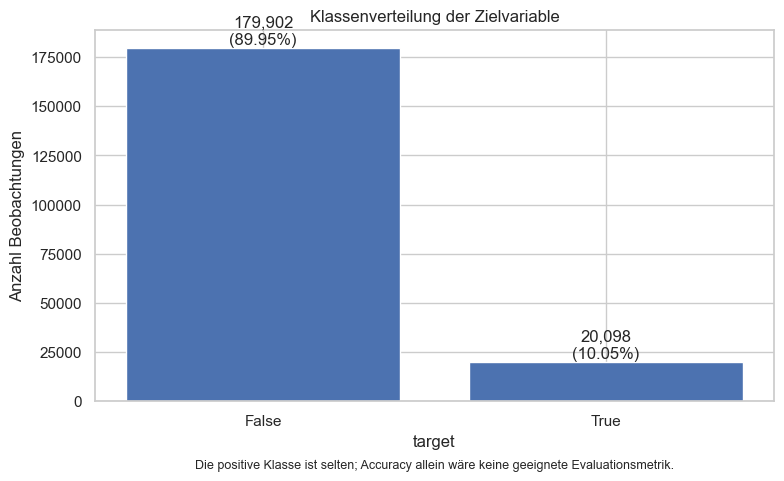

,target,count,share_percent
0,False,179902,89.951
1,True,20098,10.049


In [4]:
class_summary = y.value_counts().sort_index().rename_axis(TARGET).reset_index(name="count")
class_summary["share_percent"] = class_summary["count"] / len(y) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_summary[TARGET].astype(str), class_summary["count"])
for bar, (_, row) in zip(bars, class_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(row['count']):,}\n({row['share_percent']:.2f}%)",
        ha="center",
        va="bottom",
    )
ax.set_title("Klassenverteilung der Zielvariable")
ax.set_xlabel("target")
ax.set_ylabel("Anzahl Beobachtungen")
ax.text(
    0.5, -0.18,
    "Die positive Klasse ist selten; Accuracy allein wäre keine geeignete Evaluationsmetrik.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
)
fig.tight_layout()
fig.savefig(ASSET_PATH / "klassenimbalance.png", dpi=180, bbox_inches="tight")
plt.show()
display(class_summary)


## 2. Grundstruktur der Features

### 2.1 Deskriptive Statistik

Für jedes Feature werden Lage, Streuung, Schiefe und Kurtosis berechnet. Die Zielvariable
wird hier bewusst **nicht** in die Feature-Statistiktabelle aufgenommen.


In [5]:
descriptive_statistics = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "mean": X.mean(),
    "median": X.median(),
    "variance": X.var(),
    "std_dev": X.std(),
    "skewness": X.skew(),
    "kurtosis": X.kurtosis(),
})
print("Form der Statistik-Tabelle:", descriptive_statistics.shape)
display(descriptive_statistics.round(6))


Form der Statistik-Tabelle: (200, 8)


,min,max,mean,median,variance,std_dev,skewness,kurtosis
var_0,0.4084,20.3150,10.679914,10.52475,9.241909,3.040051,0.235639,-0.273593
var_1,-15.0434,10.3768,-1.627622,-1.60805,16.402858,4.050044,0.053115,-0.607265
var_2,2.1171,19.3530,10.715192,10.58000,6.974322,2.640894,0.260313,-0.336616
var_3,-0.0402,13.1883,6.796529,6.82500,4.175153,2.043319,-0.003548,-0.602623
var_4,5.0748,16.6714,11.078333,11.10825,2.634614,1.623150,-0.048210,-0.534993
...,...,...,...,...,...,...,...,...
var_195,-5.2610,4.2729,-0.142088,-0.17270,2.043105,1.429372,0.124048,-0.322714
var_196,-14.2096,18.3215,2.303335,2.40890,29.750144,5.454369,-0.032527,-0.760754
var_197,5.9606,12.0004,8.908158,8.88820,0.849394,0.921625,-0.031094,-0.453045
var_198,6.2993,26.0791,15.870720,15.93405,9.065793,3.010945,-0.170156,-0.294914


### 2.2 Wertebereiche, Kardinalität und Konzentration

Da die Features anonymisiert sind, wird datengetrieben geprüft, ob einzelne Variablen
diskret, nahezu konstant oder stark auf einzelne Werte konzentriert wirken.


In [6]:
feature_dtypes = X.dtypes
negative_counts = (X < 0).sum()

concentration = pd.DataFrame({
    "dtype": feature_dtypes.astype(str),
    "unique_values": X.nunique(dropna=False),
    "unique_share_percent": X.nunique(dropna=False) / len(X) * 100,
    "dominant_value_share_percent": [
        X[column].value_counts(normalize=True, dropna=False).iloc[0] * 100
        for column in feature_columns
    ],
})

negative_feature_summary = pd.DataFrame({
    "negative_count": negative_counts,
    "negative_share_percent": negative_counts / len(X) * 100,
})

print("Alle 200 Features sind Float:", bool((feature_dtypes == "float64").all()))
print("Features mit mindestens einem negativen Wert:", int((negative_counts > 0).sum()))
print("Features mit Dominanz eines Wertes >= 90 %:",
      int((concentration["dominant_value_share_percent"] >= 90).sum()))
print("Features mit maximal 20 verschiedenen Werten:",
      int((concentration["unique_values"] <= 20).sum()))

display(concentration.sort_values("dominant_value_share_percent", ascending=False).head(20).round(4))
display(negative_feature_summary.sort_values("negative_share_percent", ascending=False).head(20).round(4))


Alle 200 Features sind Float: True
Features mit mindestens einem negativen Wert: 131
Features mit Dominanz eines Wertes >= 90 %: 0
Features mit maximal 20 verschiedenen Werten: 0


,dtype,unique_values,unique_share_percent,dominant_value_share_percent
var_68,float64,451,0.2255,0.5420
var_108,float64,8525,4.2625,0.1565
var_126,float64,32411,16.2055,0.1525
var_12,float64,9561,4.7805,0.1015
var_91,float64,7962,3.9810,0.0330
var_103,float64,9376,4.6880,0.0305
var_148,float64,10608,5.3040,0.0295
var_71,float64,13527,6.7635,0.0270
var_161,float64,11071,5.5355,0.0260
var_25,float64,14853,7.4265,0.0205


,negative_count,negative_share_percent
var_90,177075,88.5375
var_47,172883,86.4415
var_61,166965,83.4825
var_30,161693,80.8465
var_157,160657,80.3285
var_187,157961,78.9805
var_69,157756,78.8780
var_185,157547,78.7735
var_17,157265,78.6325
var_40,156749,78.3745


### 2.3 EDA-Skalierung für vergleichende Darstellungen

Für skalenabhängige **explorative** Analysen wird eine Min-Max-Version der Features erzeugt.
Diese auf dem vollständigen Datensatz berechnete Matrix wird nicht für eine berichtete
Testleistung verwendet. Die überwachte Baseline weiter unten besitzt eine eigene leakage-freie
Pipeline.


In [7]:
feature_min = X.min()
feature_max = X.max()
feature_range = feature_max - feature_min
constant_features = feature_range[feature_range == 0].index.tolist()

X_minmax = (X - feature_min) / feature_range.replace(0, 1)

print("Anzahl konstanter Features:", len(constant_features))
print("Normalisierte Matrix:", X_minmax.shape)
print("Globales Minimum:", X_minmax.min().min())
print("Globales Maximum:", X_minmax.max().max())


Anzahl konstanter Features: 0
Normalisierte Matrix: (200000, 200)
Globales Minimum: 0.0


Globales Maximum: 1.0


### 2.4 Ausreißerindikatoren, Heavy Tails und relative Streuung

Die 1,5-IQR-Regel dient nur als **deskriptive Extremwertmarkierung**. Sie ist keine
automatische Löschregel. Für den Vergleich niedriger Streuung wird die normalisierte IQR
verwendet; rohe Varianzen unterschiedlich skalierter Features wären nicht direkt vergleichbar.


,outlier_share_percent,minmax_iqr,skewness,kurtosis
var_179,0.7545,0.1767,0.2429,-0.0140
var_44,0.6040,0.1761,-0.3402,-0.0965
var_93,0.4445,0.1853,-0.2381,-0.1524
var_146,0.4020,0.1732,-0.1251,-0.1680
var_192,0.3665,0.1686,0.0840,-0.2396
var_31,0.3185,0.1672,0.0747,-0.2613
var_133,0.2945,0.1788,0.1250,-0.2601
var_105,0.2860,0.1832,0.1246,-0.2147
var_38,0.2510,0.1661,0.1110,-0.3213
var_124,0.2490,0.1741,-0.0546,-0.2940


,outlier_share_percent,minmax_iqr,skewness,kurtosis
var_149,0.1915,0.1629,-0.0156,-0.3284
var_28,0.0965,0.1645,-0.0416,-0.3666
var_38,0.2510,0.1661,0.1110,-0.3213
var_31,0.3185,0.1672,0.0747,-0.2613
var_52,0.1765,0.1676,-0.0123,-0.3499
var_192,0.3665,0.1686,0.0840,-0.2396
var_146,0.4020,0.1732,-0.1251,-0.1680
var_124,0.2490,0.1741,-0.0546,-0.2940
var_67,0.2325,0.1745,0.0145,-0.2897
var_44,0.6040,0.1761,-0.3402,-0.0965


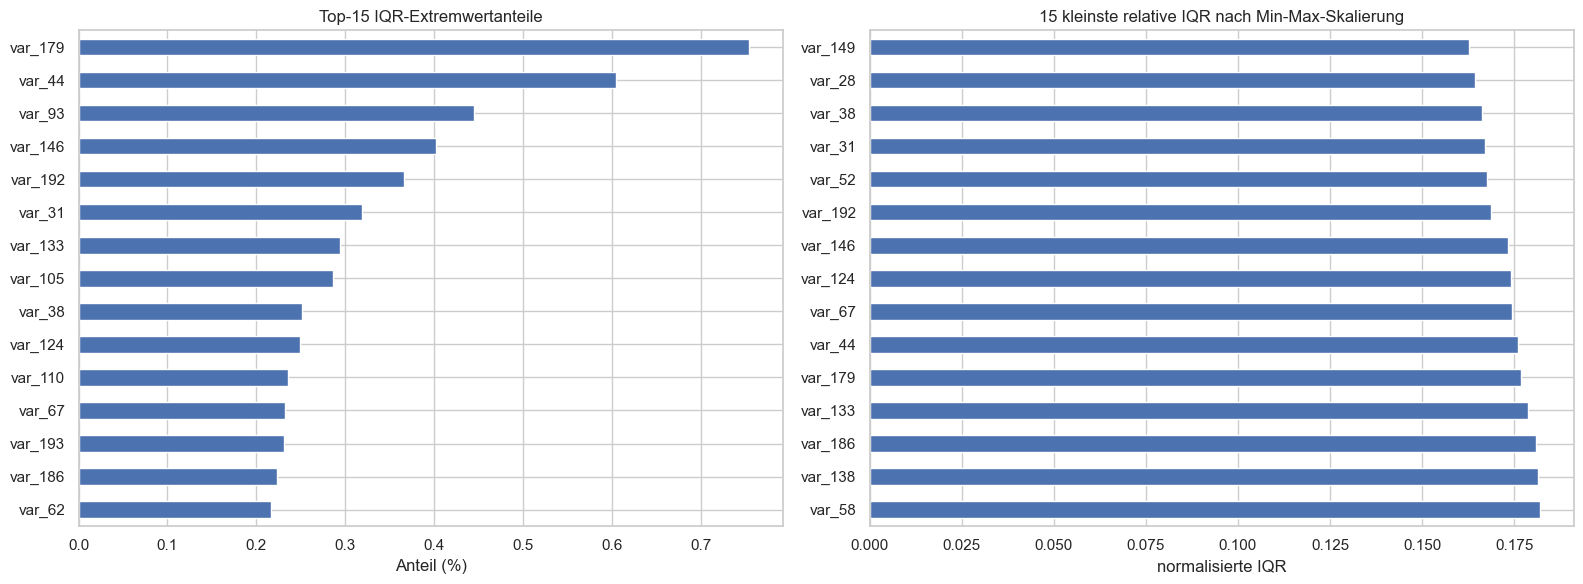

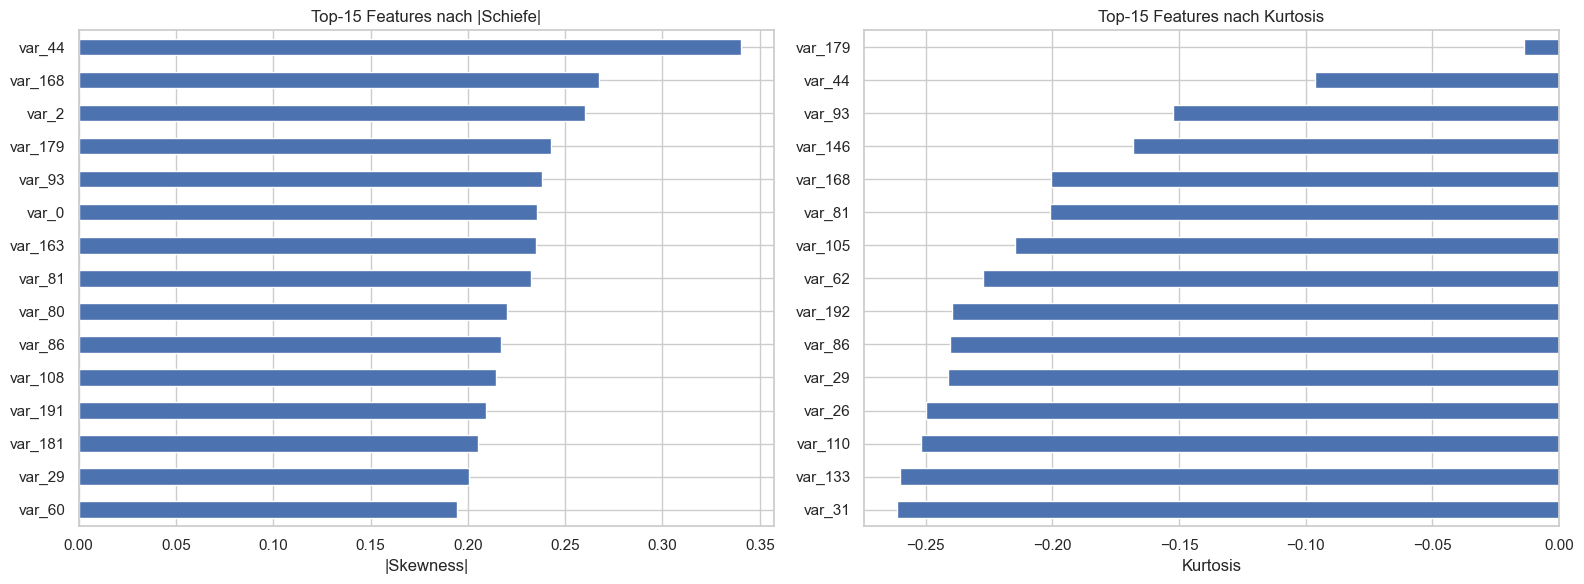

In [8]:
q1, q3 = X.quantile(0.25), X.quantile(0.75)
iqr = q3 - q1
outlier_mask = X.lt(q1 - 1.5 * iqr) | X.gt(q3 + 1.5 * iqr)

minmax_iqr = X_minmax.quantile(0.75) - X_minmax.quantile(0.25)

outlier_summary = pd.DataFrame({
    "outlier_share_percent": outlier_mask.mean() * 100,
    "minmax_iqr": minmax_iqr,
    "skewness": X.skew(),
    "kurtosis": X.kurtosis(),
})

display(
    outlier_summary.sort_values("outlier_share_percent", ascending=False)
                   .head(15)
                   .round(4)
)
display(
    outlier_summary.sort_values("minmax_iqr")
                   .head(15)
                   .round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
outlier_summary["outlier_share_percent"].nlargest(15).sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Top-15 IQR-Extremwertanteile")
axes[0].set_xlabel("Anteil (%)")

outlier_summary["minmax_iqr"].nsmallest(15).sort_values(ascending=False).plot.barh(ax=axes[1])
axes[1].set_title("15 kleinste relative IQR nach Min-Max-Skalierung")
axes[1].set_xlabel("normalisierte IQR")

fig.tight_layout()
fig.savefig(ASSET_PATH / "ausreisser_und_niedrige_streuung.png", dpi=180, bbox_inches="tight")
plt.show()

shape_summary = outlier_summary[["skewness", "kurtosis"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
shape_summary["skewness"].abs().nlargest(15).sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Top-15 Features nach |Schiefe|")
axes[0].set_xlabel("|Skewness|")

shape_summary["kurtosis"].nlargest(15).sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Top-15 Features nach Kurtosis")
axes[1].set_xlabel("Kurtosis")

fig.tight_layout()
fig.savefig(
    ASSET_PATH / "schiefe_und_kurtosis_top15.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## 3. Unterschiede zwischen `target=False` und `target=True`

### 3.1 Effektgrößen: Mittelwerte, Mediane und Cohen's d

Rohe Mittelwertdifferenzen sind wegen unterschiedlicher Feature-Skalen nicht direkt
vergleichbar. Deshalb wird zusätzlich Cohen's d mit der nach Gruppengrößen gepoolten
Standardabweichung berechnet.


_label,mean_false,mean_true,median_false,median_true,std_false,std_true,mean_difference_true_minus_false,median_difference_true_minus_false,pooled_std,cohens_d,abs_cohens_d
var_81,14.781217,14.162315,14.89180,14.33640,2.257984,2.576855,-0.618902,-0.55540,2.292032,-0.270023,0.270023
var_139,7.950512,6.056607,8.23655,6.18245,7.587266,8.331637,-1.893905,-2.05410,7.665332,-0.247074,0.247074
var_12,14.028392,13.984464,14.02960,13.98260,0.187441,0.207935,-0.043928,-0.04700,0.189600,-0.231687,0.231687
var_6,5.389620,5.581966,5.36440,5.60180,0.857983,0.922442,0.192346,0.23740,0.864678,0.222448,0.222448
var_110,5.431102,6.248459,5.32440,6.12600,3.776002,4.151065,0.817357,0.80160,3.815357,0.214228,0.214228
var_146,10.394760,9.861549,10.44350,9.91900,2.489328,2.722928,-0.533211,-0.52450,2.513783,-0.212115,0.212115
var_53,5.992363,6.153627,6.01130,6.16705,0.756300,0.822540,0.161263,0.15575,0.763216,0.211294,0.211294
var_26,-4.178694,-2.949112,-4.29860,-3.11795,5.847831,6.446004,1.229581,1.18065,5.910675,0.208027,0.208027
var_76,6.215158,4.580307,6.47200,4.64565,7.858068,8.483437,-1.634850,-1.82635,7.923140,-0.206339,0.206339
var_174,20.357774,18.893971,20.34655,18.93740,7.064789,7.623027,-1.463803,-1.40915,7.122861,-0.205508,0.205508


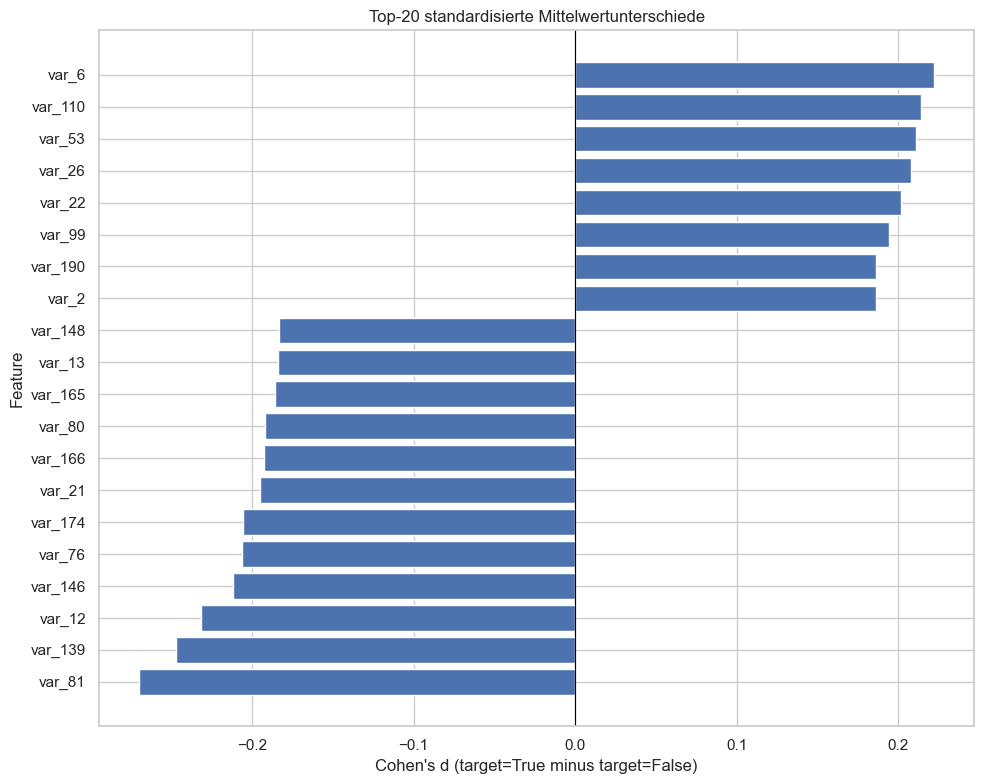

In [9]:
grouped = X.assign(_label=y.to_numpy()).groupby("_label")

mean_by_label = grouped[feature_columns].mean().T.rename(
    columns={False: "mean_false", True: "mean_true"}
)
median_by_label = grouped[feature_columns].median().T.rename(
    columns={False: "median_false", True: "median_true"}
)
std_by_label = grouped[feature_columns].std().T.rename(
    columns={False: "std_false", True: "std_true"}
)

feature_comparison = mean_by_label.join(median_by_label).join(std_by_label)
feature_comparison["mean_difference_true_minus_false"] = (
    feature_comparison["mean_true"] - feature_comparison["mean_false"]
)
feature_comparison["median_difference_true_minus_false"] = (
    feature_comparison["median_true"] - feature_comparison["median_false"]
)

n_false = int((y == False).sum())
n_true = int((y == True).sum())

feature_comparison["pooled_std"] = np.sqrt(
    (
        (n_false - 1) * feature_comparison["std_false"] ** 2
        + (n_true - 1) * feature_comparison["std_true"] ** 2
    )
    / (n_false + n_true - 2)
)
feature_comparison["cohens_d"] = (
    feature_comparison["mean_difference_true_minus_false"]
    / feature_comparison["pooled_std"].replace(0, np.nan)
)
feature_comparison["abs_cohens_d"] = feature_comparison["cohens_d"].abs()
feature_comparison = feature_comparison.sort_values("abs_cohens_d", ascending=False)

display(feature_comparison.head(25).round(6))

top_effects = feature_comparison.head(20).sort_values("cohens_d")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_effects.index, top_effects["cohens_d"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top-20 standardisierte Mittelwertunterschiede")
ax.set_xlabel("Cohen's d (target=True minus target=False)")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(ASSET_PATH / "top20_cohens_d.png", dpi=180, bbox_inches="tight")
plt.show()


### 3.2 Verteilungsvergleich in **einer** gemeinsamen Violinplot-Übersicht

Statt mehrere nahezu identische Violinplot-Blöcke an verschiedenen Stellen zu zeigen,
werden hier einmalig 15 Features gegenübergestellt:

- fünf größte positive Cohen-d-Effekte,
- fünf größte negative Cohen-d-Effekte,
- fünf Features mit nahezu keiner Mittelwertdifferenz als Vergleich.

Die fünf letzten Features sind nur bezüglich Cohen's d „ähnlich“; das bedeutet nicht,
dass ihre vollständigen Verteilungen identisch sind.


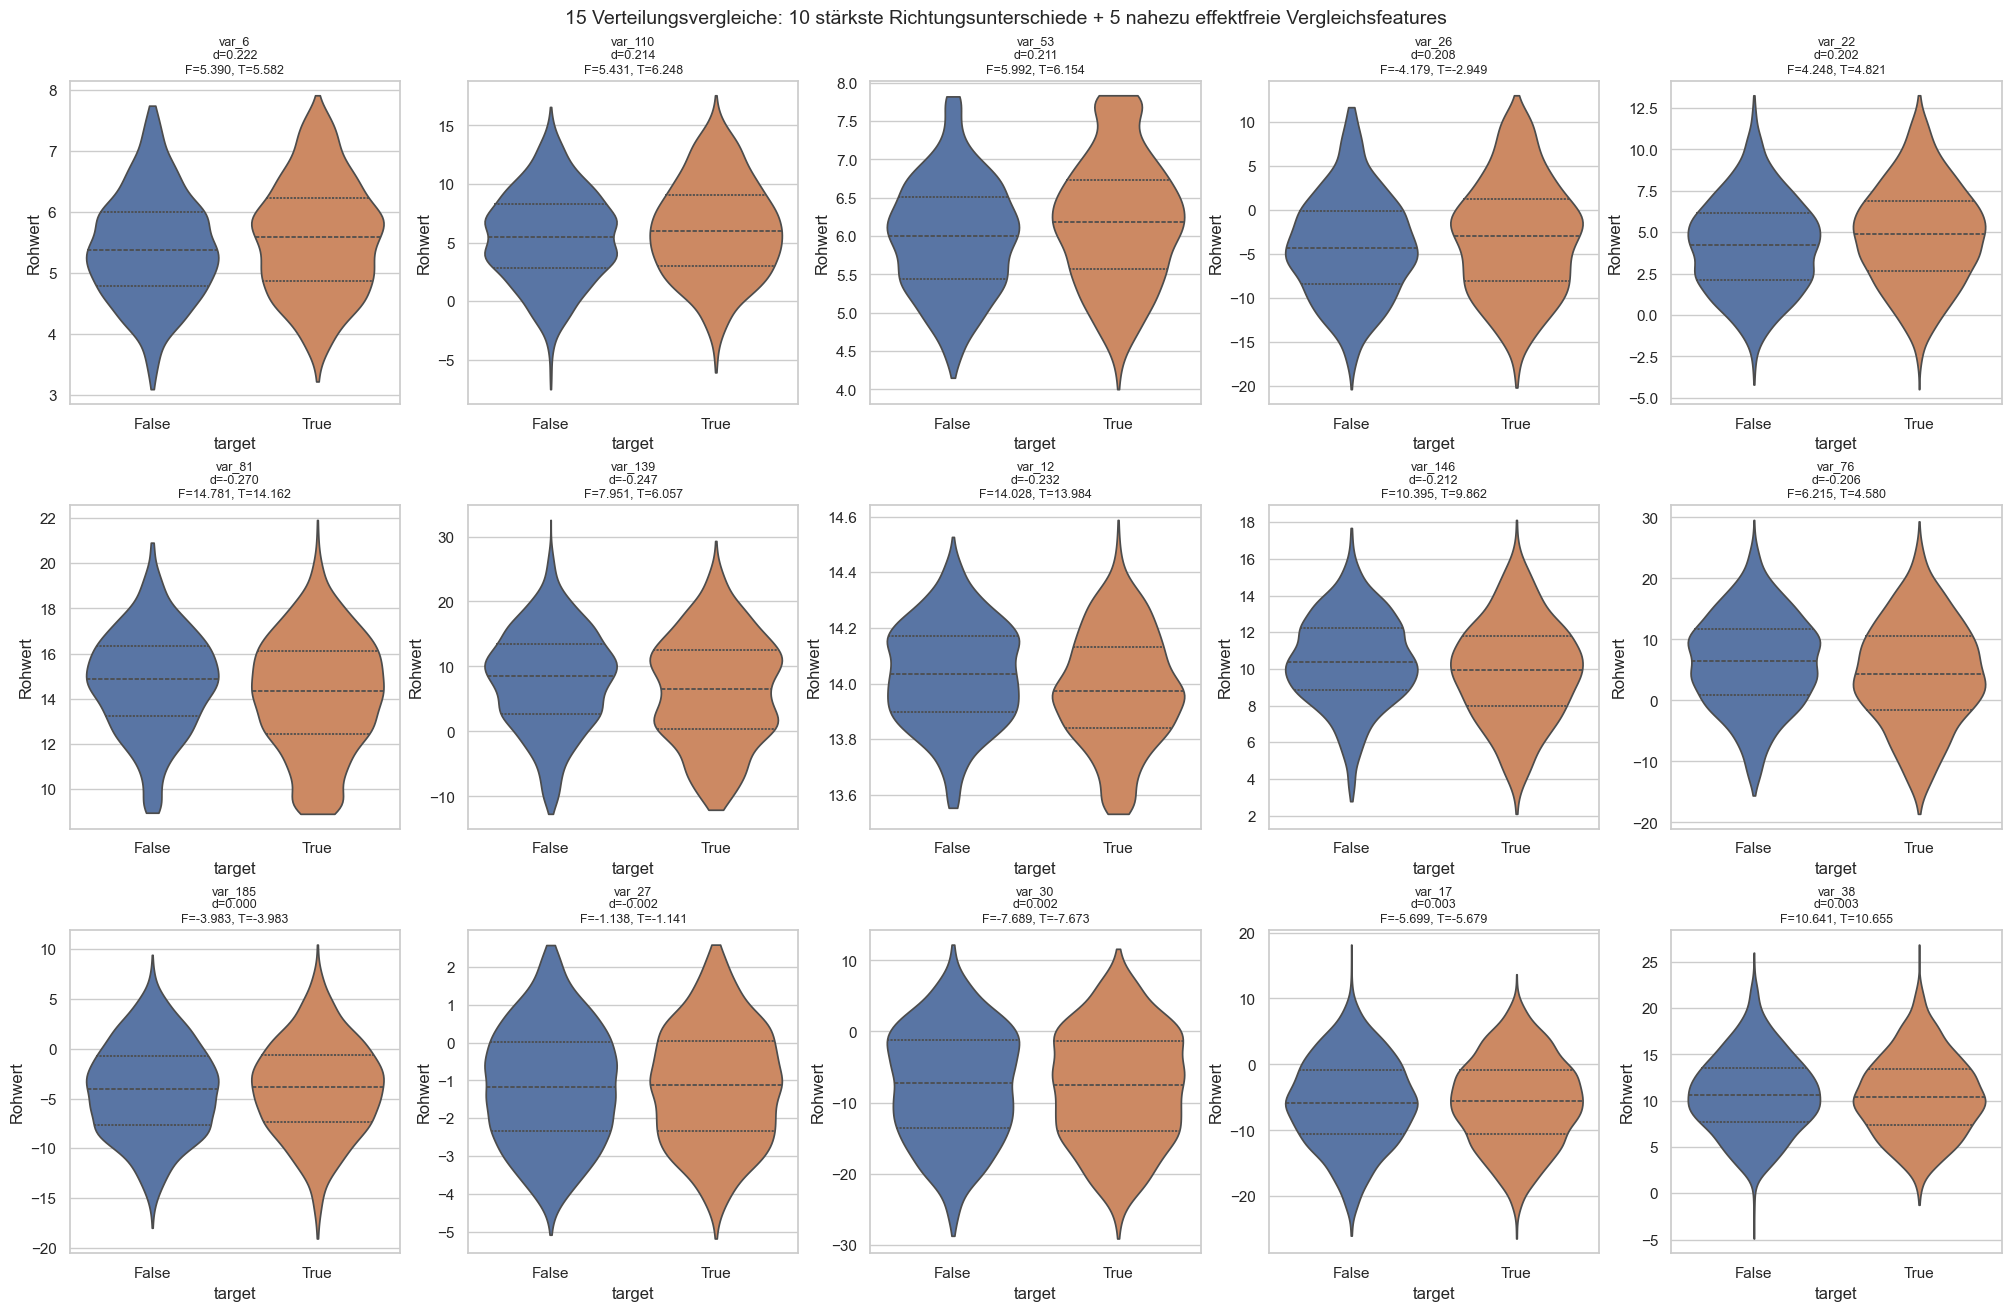

Positive Top-5: ['var_6', 'var_110', 'var_53', 'var_26', 'var_22']
Negative Top-5: ['var_81', 'var_139', 'var_12', 'var_146', 'var_76']
Nahezu effektfreie Vergleichsfeatures: ['var_185', 'var_27', 'var_30', 'var_17', 'var_38']


In [10]:
plot_sample = pd.concat(
    [
        part.sample(n=min(2000, len(part)), random_state=RANDOM_STATE)
        for _, part in df.groupby(TARGET)
    ],
    axis=0,
)

positive_features = (
    feature_comparison.sort_values("cohens_d", ascending=False).head(5).index.tolist()
)
negative_features = (
    feature_comparison.sort_values("cohens_d", ascending=True).head(5).index.tolist()
)
lowest_effect_features = (
    feature_comparison["abs_cohens_d"].nsmallest(5).index.tolist()
)

violin_features = positive_features + negative_features + [
    feature for feature in lowest_effect_features
    if feature not in positive_features + negative_features
]
assert len(violin_features) == 15

fig, axes = plt.subplots(3, 5, figsize=(20, 13), constrained_layout=True)
for ax, feature in zip(axes.flat, violin_features):
    sns.violinplot(
        data=plot_sample,
        x=TARGET,
        y=feature,
        hue=TARGET,
        legend=False,
        cut=0,
        inner="quartile",
        ax=ax,
    )
    row = feature_comparison.loc[feature]
    ax.set_title(
        f"{feature}\nd={row['cohens_d']:.3f}\n"
        f"F={row['mean_false']:.3f}, T={row['mean_true']:.3f}",
        fontsize=9,
    )
    ax.set_xlabel("target")
    ax.set_ylabel("Rohwert")

fig.suptitle(
    "15 Verteilungsvergleiche: 10 stärkste Richtungsunterschiede + 5 nahezu effektfreie Vergleichsfeatures",
    fontsize=14,
)
combined_violin_path = ASSET_PATH / "all_15_violinplots_combined.png"
fig.savefig(combined_violin_path, dpi=180, bbox_inches="tight")
plt.show()

print("Positive Top-5:", positive_features)
print("Negative Top-5:", negative_features)
print("Nahezu effektfreie Vergleichsfeatures:", lowest_effect_features)


### 3.3 Inferenz: Welch-Tests mit Benjamini-Hochberg-FDR

Welch-Tests prüfen pro Feature Mittelwertunterschiede, ohne gleiche Varianzen vorauszusetzen.
Die Benjamini-Hochberg-Korrektur begrenzt die False Discovery Rate über die 200 parallelen
Tests. Die p-Werte werden über den Feature-Namen ausgerichtet, damit die zuvor nach
Effektgröße sortierte Tabelle keine Zuordnungsfehler erzeugt. Bei 200.000 Beobachtungen
können sehr kleine Effekte hochsignifikant sein; p-Werte werden deshalb nur gemeinsam
mit Cohen's d interpretiert.


,mean_difference_true_minus_false,cohens_d,abs_cohens_d,p_value_welch,p_value_fdr_bh,significant_fdr_0.05
var_81,-0.618902,-0.270023,0.270023,0.0,0.0,True
var_139,-1.893905,-0.247074,0.247074,0.0,0.0,True
var_12,-0.043928,-0.231687,0.231687,0.0,0.0,True
var_6,0.192346,0.222448,0.222448,0.0,0.0,True
var_110,0.817357,0.214228,0.214228,0.0,0.0,True
var_53,0.161263,0.211294,0.211294,0.0,0.0,True
var_146,-0.533211,-0.212115,0.212115,0.0,0.0,True
var_76,-1.634850,-0.206339,0.206339,0.0,0.0,True
var_174,-1.463803,-0.205508,0.205508,0.0,0.0,True
var_26,1.229581,0.208027,0.208027,0.0,0.0,True


FDR-signifikante Features: 181 von 200


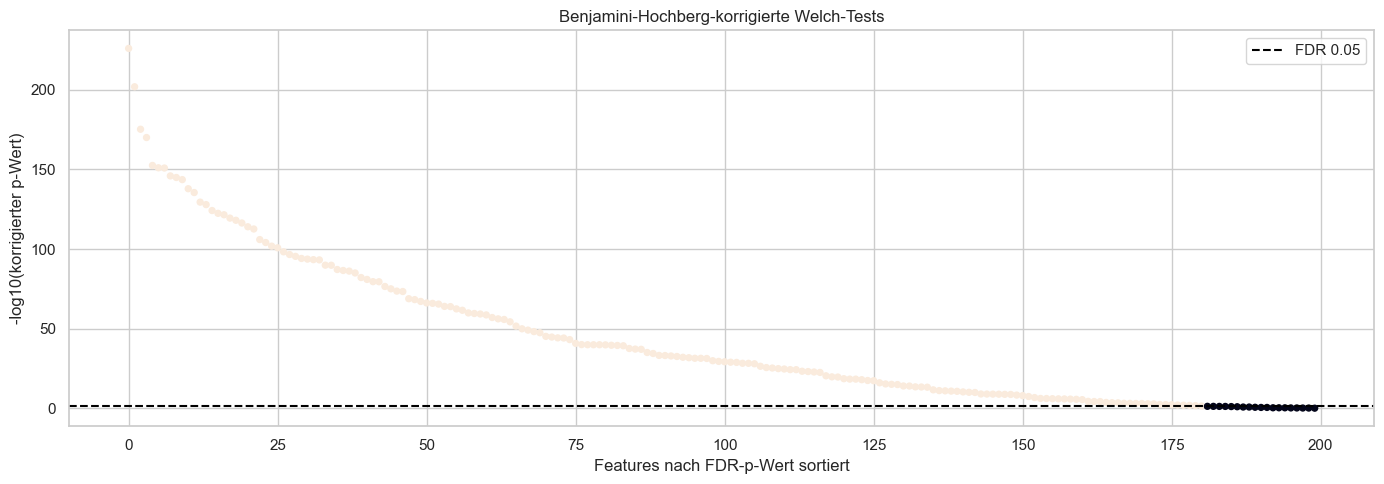

In [11]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order]

    adjusted_ranked = np.minimum.accumulate(
        (ranked * len(p_values) / np.arange(1, len(p_values) + 1))[::-1]
    )[::-1]

    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.minimum(adjusted_ranked, 1.0)
    return adjusted

false_values = X.loc[y == False]
true_values = X.loc[y == True]

raw_p = pd.Series(
    {
        feature: ttest_ind(
            false_values[feature],
            true_values[feature],
            equal_var=False,
        ).pvalue
        for feature in feature_columns
    },
    name="p_value_welch",
)
adjusted_p = pd.Series(
    benjamini_hochberg(raw_p.to_numpy()),
    index=raw_p.index,
    name="p_value_fdr_bh",
)

multiple_testing = feature_comparison[
    ["mean_difference_true_minus_false", "cohens_d", "abs_cohens_d"]
].copy()
# Explizite Indexausrichtung verhindert eine falsche Feature-p-Wert-Zuordnung,
# nachdem feature_comparison zuvor nach |Cohen's d| sortiert wurde.
multiple_testing = multiple_testing.join(raw_p).join(adjusted_p)
multiple_testing["significant_fdr_0.05"] = (
    multiple_testing["p_value_fdr_bh"] < 0.05
)
multiple_testing = multiple_testing.sort_values("p_value_fdr_bh")

display(multiple_testing.head(20).round(8))
print(
    "FDR-signifikante Features:",
    int(multiple_testing["significant_fdr_0.05"].sum()),
    "von",
    len(feature_columns),
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(
    range(len(multiple_testing)),
    -np.log10(multiple_testing["p_value_fdr_bh"].clip(lower=1e-300)),
    c=multiple_testing["significant_fdr_0.05"].map({True: 1, False: 0}),
    s=18,
)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", label="FDR 0.05")
ax.set_title("Benjamini-Hochberg-korrigierte Welch-Tests")
ax.set_xlabel("Features nach FDR-p-Wert sortiert")
ax.set_ylabel("-log10(korrigierter p-Wert)")
ax.legend()
fig.tight_layout()
fig.savefig(ASSET_PATH / "fdr_welch_tests_200_features.png", dpi=180, bbox_inches="tight")
plt.show()


### 3.4 Stabilität der Effektgrößen über mehrere 1:1-Teilstichproben

Alle positiven Fälle bleiben erhalten; aus der größeren negativen Klasse werden mit fünf
Seeds gleich große Teilstichproben gezogen. Das prüft, ob die Rangfolge der Cohen-d-Effekte
stark von einer einzelnen Auswahl negativer Beobachtungen abhängt.


Spearman-Rangkorrelationen der Cohen-d-Ranglisten:


,42,43,44,45,46
42,1.0000,0.9965,0.9961,0.9963,0.9961
43,0.9965,1.0000,0.9966,0.9964,0.9959
44,0.9961,0.9966,1.0000,0.9965,0.9965
45,0.9963,0.9964,0.9965,1.0000,0.9961
46,0.9961,0.9959,0.9965,0.9961,1.0000


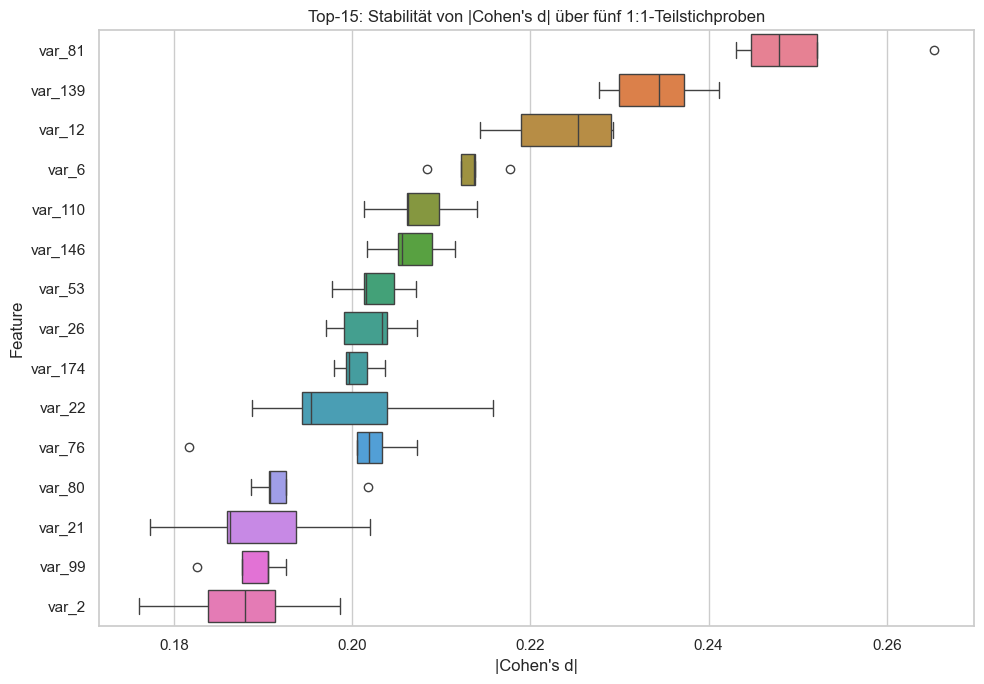

In [12]:
false_indices = df.index[y == False].to_numpy()
true_indices = df.index[y == True].to_numpy()

STABILITY_SEEDS = [42, 43, 44, 45, 46]
stability_effects = {}

for seed in STABILITY_SEEDS:
    sampled_false_idx = pd.Series(false_indices).sample(
        n=len(true_indices),
        random_state=seed,
        replace=False,
    ).to_numpy()

    false_sample = X.loc[sampled_false_idx]
    true_sample = X.loc[true_indices]

    n0, n1 = len(false_sample), len(true_sample)
    pooled_std = np.sqrt(
        (
            (n0 - 1) * false_sample.var()
            + (n1 - 1) * true_sample.var()
        )
        / (n0 + n1 - 2)
    ).replace(0, np.nan)

    stability_effects[seed] = (
        true_sample.mean() - false_sample.mean()
    ) / pooled_std

stability_effects = pd.DataFrame(stability_effects)
stability_rank_corr = stability_effects.rank().corr(method="spearman")

print("Spearman-Rangkorrelationen der Cohen-d-Ranglisten:")
display(stability_rank_corr.round(4))

top_stability_features = (
    stability_effects.abs().mean(axis=1).nlargest(15).index
)
stability_plot = stability_effects.loc[top_stability_features].abs().T

fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(data=stability_plot, orient="h", ax=ax)
ax.set_title("Top-15: Stabilität von |Cohen's d| über fünf 1:1-Teilstichproben")
ax.set_xlabel("|Cohen's d|")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(
    ASSET_PATH / "stabilitaet_cohens_d_1to1_seeds.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


### 3.5 Bootstrap-Stabilitätsintervalle der stärksten Effekte

Die fünf stärksten Features wurden zuvor aus denselben Daten ausgewählt. Die folgenden
Intervalle sind deshalb **Stabilitäts-/Sensitivitätsintervalle**, keine
selektionsunabhängigen Konfidenzintervalle.


In [13]:
BOOTSTRAP_REPS = 500
BOOTSTRAP_SAMPLE_SIZE = 5000
rng_boot = np.random.default_rng(RANDOM_STATE)

bootstrap_features = (
    feature_comparison["abs_cohens_d"].nlargest(5).index.tolist()
)

fdata = X.loc[y == False, bootstrap_features].to_numpy()
tdata = X.loc[y == True, bootstrap_features].to_numpy()

rows = []
for j, feature in enumerate(bootstrap_features):
    values = []
    for _ in range(BOOTSTRAP_REPS):
        f = fdata[
            rng_boot.integers(0, len(fdata), size=BOOTSTRAP_SAMPLE_SIZE), j
        ]
        t = tdata[
            rng_boot.integers(0, len(tdata), size=BOOTSTRAP_SAMPLE_SIZE), j
        ]

        n0, n1 = len(f), len(t)
        pooled_std = np.sqrt(
            ((n0 - 1) * f.var(ddof=1) + (n1 - 1) * t.var(ddof=1))
            / (n0 + n1 - 2)
        )
        values.append((t.mean() - f.mean()) / pooled_std)

    rows.append([
        feature,
        np.mean(values),
        np.percentile(values, 2.5),
        np.percentile(values, 97.5),
    ])

bootstrap_effect_ci = pd.DataFrame(
    rows,
    columns=["feature", "cohens_d_mean", "ci_2.5%", "ci_97.5%"],
).set_index("feature")

display(bootstrap_effect_ci.round(4))


,cohens_d_mean,ci_2.5%,ci_97.5%
feature,,,
var_81,-0.2567,-0.2957,-0.2178
var_139,-0.2378,-0.2750,-0.1986
var_12,-0.2216,-0.2598,-0.1849
var_6,0.2173,0.1754,0.2556
var_110,0.2056,0.1683,0.2438


### 3.6 Nichtlineare Einzelassoziation: Mutual Information

Mutual Information ergänzt die lineare Mittelwert- und Korrelationssicht. Die Berechnung
erfolgt aus Rechengründen auf einer reproduzierbaren 50.000er-Stichprobe und bleibt
explorativ; sie liefert weder Kausalität noch eine fertige Featureselektion.


,mutual_information,abs_cohens_d,p_value_fdr_bh
var_110,0.007433,0.214228,0.000000
var_139,0.005768,0.247074,0.000000
var_149,0.005286,0.157564,0.000000
var_148,0.004810,0.183249,0.000000
var_26,0.004539,0.208027,0.000000
var_81,0.004418,0.270023,0.000000
var_131,0.004194,0.107756,0.000000
var_44,0.003998,0.163306,0.000000
var_2,0.003892,0.186120,0.000000
var_80,0.003821,0.191933,0.000000


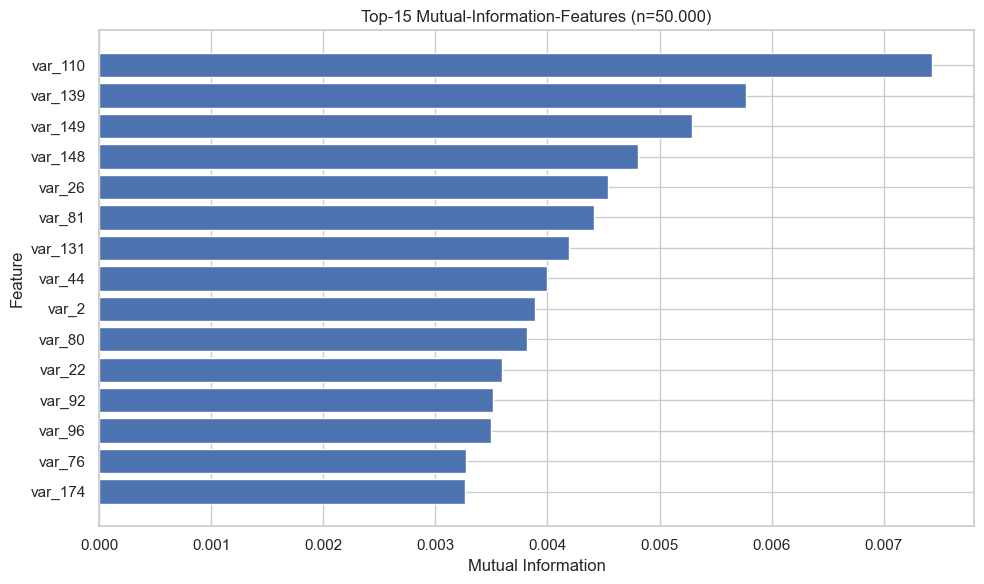

In [14]:
mi_sample = df.sample(n=min(50_000, len(df)), random_state=RANDOM_STATE)

mi_values = mutual_info_classif(
    mi_sample[feature_columns],
    mi_sample[TARGET].astype(int),
    random_state=RANDOM_STATE,
)

mutual_information = (
    pd.DataFrame({"mutual_information": mi_values}, index=feature_columns)
      .sort_values("mutual_information", ascending=False)
      .join(multiple_testing[["abs_cohens_d", "p_value_fdr_bh"]])
)

display(mutual_information.head(20).round(6))

top_mi = mutual_information.head(15).sort_values("mutual_information")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_mi.index, top_mi["mutual_information"])
ax.set_title("Top-15 Mutual-Information-Features (n=50.000)")
ax.set_xlabel("Mutual Information")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(ASSET_PATH / "mutual_information_top15.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. Korrelationen und lineare Redundanz

### 4.1 Globale Feature-Korrelationen und Target-Assoziationen

Die Pearson-Korrelation wird **nur zwischen Features** berechnet. Die Korrelation eines
kontinuierlichen Features mit dem binären `target` wird separat ausgewiesen; sie ist numerisch
äquivalent zur punkt-biserialen Korrelation und beschreibt eine lineare Gruppenassoziation,
keine Kausalität.


Stärkste Feature-Feature-Korrelationen:


correlation  abs_correlation
var_26  var_139    -0.009844         0.009844
var_53  var_148    -0.009788         0.009788
var_81  var_165     0.009714         0.009714
        var_174     0.009490         0.009490
var_183 var_189     0.009359         0.009359
var_146 var_169     0.009071         0.009071
var_6   var_80     -0.008958         0.008958
var_122 var_132     0.008956         0.008956
var_81  var_172     0.008936         0.008936
var_1   var_80     -0.008855         0.008855
var_2   var_13     -0.008795         0.008795
var_81  var_155    -0.008601         0.008601
var_12  var_146     0.008591         0.008591
var_127 var_162    -0.008555         0.008555
var_54  var_179    -0.008394         0.008394
var_172 var_193     0.008163         0.008163
var_6   var_157     0.008076         0.008076
var_26  var_72     -0.008062         0.008062
var_167 var_173     0.008045         0.008045
var_34  var_133    -0.008020         0.008020

Stärkste lineare Feature-Target-Assoziationen:


,corr_with_target,abs_corr_with_target
var_81,-0.080917,0.080917
var_139,-0.074080,0.074080
var_12,-0.069489,0.069489
var_6,0.066731,0.066731
var_110,0.064275,0.064275
var_146,-0.063644,0.063644
var_53,0.063399,0.063399
var_26,0.062422,0.062422
var_76,-0.061917,0.061917
var_174,-0.061669,0.061669


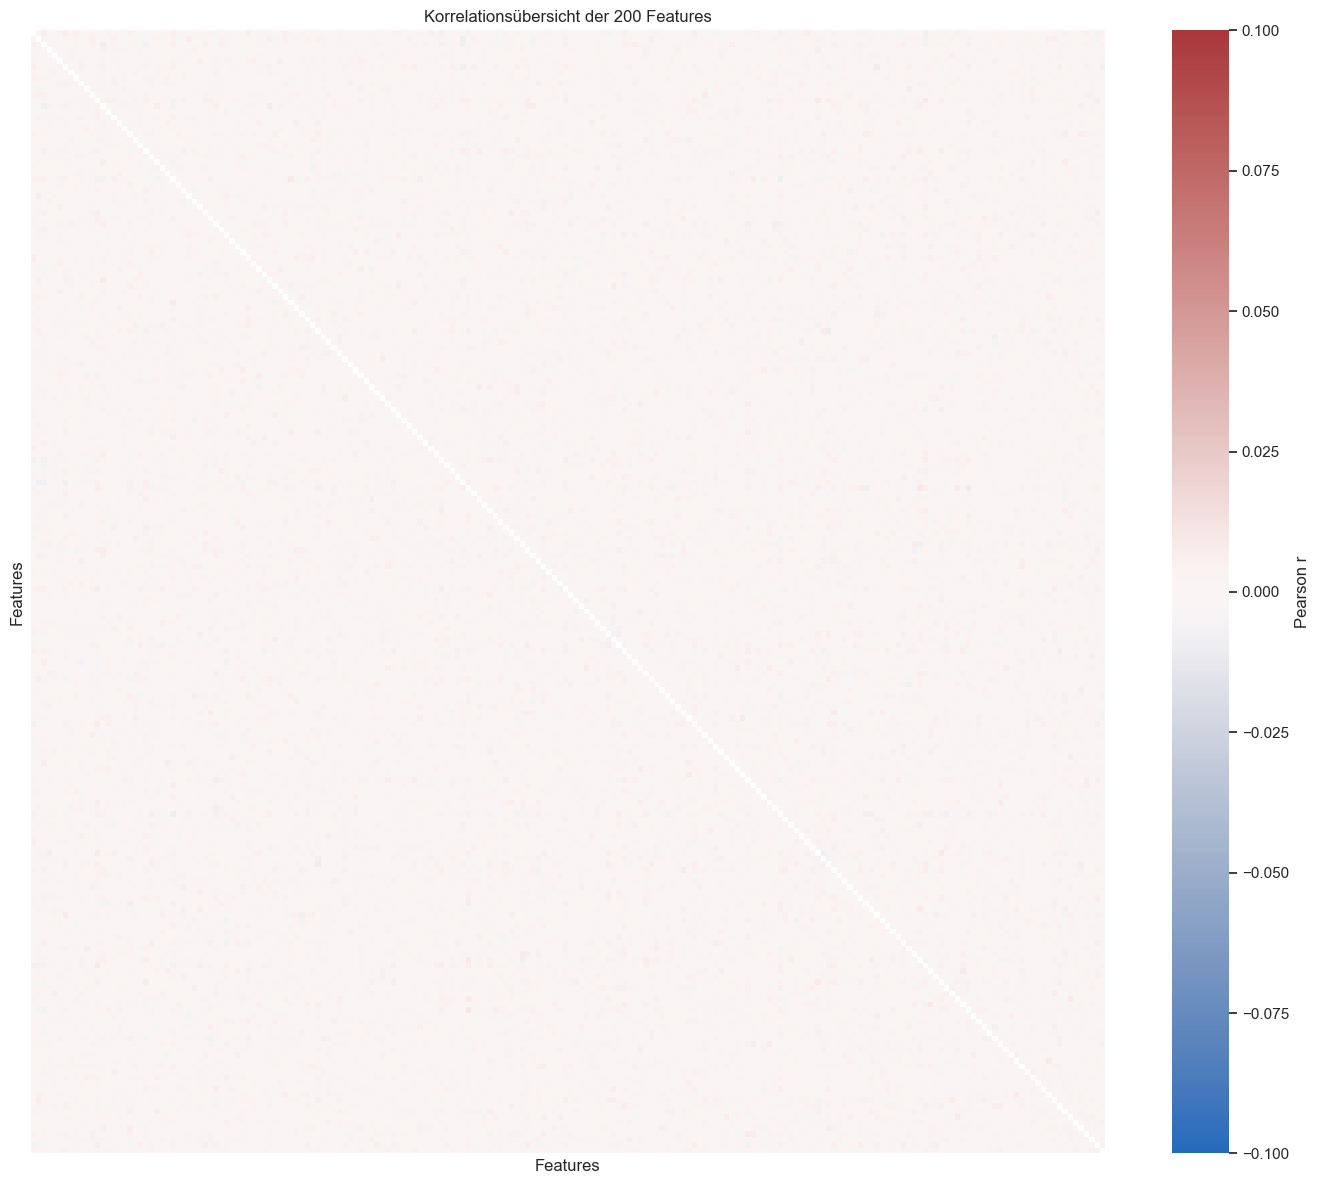

In [15]:
correlation_matrix = X.corr(method="pearson")

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
strongest_feature_correlations = (
    upper_triangle.stack()
    .rename("correlation")
    .to_frame()
    .assign(abs_correlation=lambda frame: frame["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
)

target_correlations = (
    X.corrwith(y.astype(float))
     .rename("corr_with_target")
     .to_frame()
     .assign(abs_corr_with_target=lambda frame: frame["corr_with_target"].abs())
     .sort_values("abs_corr_with_target", ascending=False)
)

print("Stärkste Feature-Feature-Korrelationen:")
display(strongest_feature_correlations.head(20).round(6))

print("Stärkste lineare Feature-Target-Assoziationen:")
display(target_correlations.head(20).round(6))

feature_correlation_for_plot = correlation_matrix.mask(
    np.eye(len(feature_columns), dtype=bool)
)
corr_plot_limit = max(
    0.10,
    float(np.nanmax(np.abs(feature_correlation_for_plot.to_numpy()))),
)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    feature_correlation_for_plot,
    cmap="vlag",
    center=0,
    vmin=-corr_plot_limit,
    vmax=corr_plot_limit,
    xticklabels=False,
    yticklabels=False,
    ax=ax,
    cbar_kws={"label": "Pearson r"},
)
ax.set_title("Korrelationsübersicht der 200 Features")
ax.set_xlabel("Features")
ax.set_ylabel("Features")
fig.tight_layout()
fig.savefig(ASSET_PATH / "korrelations_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


### 4.2 Prüfung auf starke lineare Redundanz

Ein Schwellenwert von $|r| \geq 0{,}8$ wird als einfache Diagnose für sehr starke lineare
Redundanz verwendet. Das ist keine vollständige Multikollinearitätsanalyse, liefert aber einen
klaren ersten Hinweis.


Stark korrelierte Paare |r| >= 0.8: 0


,,abs_pearson_r


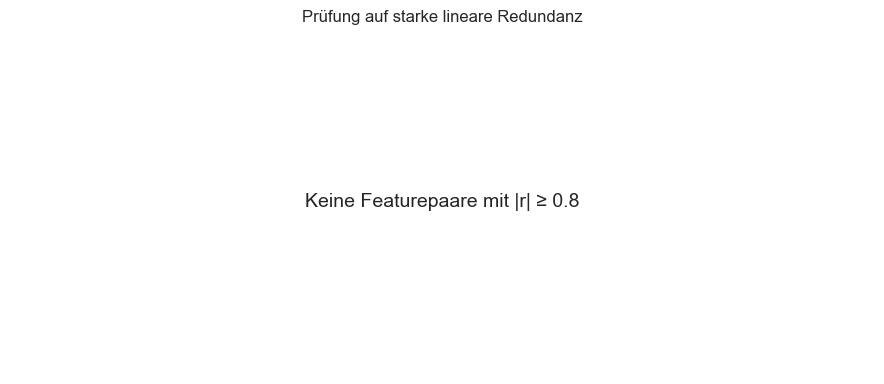

In [16]:
corr_abs = correlation_matrix.abs()
redundancy_pairs = (
    corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
            .stack()
            .sort_values(ascending=False)
)
redundancy_pairs = redundancy_pairs[redundancy_pairs >= 0.8]

print("Stark korrelierte Paare |r| >= 0.8:", len(redundancy_pairs))
display(redundancy_pairs.head(20).rename("abs_pearson_r").to_frame())

fig, ax = plt.subplots(figsize=(9, 4))
if len(redundancy_pairs) == 0:
    ax.axis("off")
    ax.text(
        0.5, 0.5,
        "Keine Featurepaare mit |r| ≥ 0.8",
        ha="center",
        va="center",
        fontsize=14,
    )
    ax.set_title("Prüfung auf starke lineare Redundanz")
else:
    redundancy_counts = pd.Series(0, index=feature_columns, dtype=int)
    for (a, b), _ in redundancy_pairs.items():
        redundancy_counts[a] += 1
        redundancy_counts[b] += 1
    redundancy_counts.nlargest(15).sort_values().plot.barh(ax=ax)
    ax.set_title("Features mit den meisten stark korrelierten Partnern")
    ax.set_xlabel("Anzahl Partner")

fig.tight_layout()
fig.savefig(
    ASSET_PATH / "redundanz_stark_korrelierte_features.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


### 4.3 Label-konditionierte Feature-Korrelationen

Die Korrelationen werden innerhalb beider Klassen separat berechnet. Die Differenz
`corr_true - corr_false` zeigt, welche **linearen Feature-Feature-Beziehungen** sich zwischen
den Gruppen verändern. Beide Klassenmatrizen erhalten dieselbe symmetrische Farbskala.


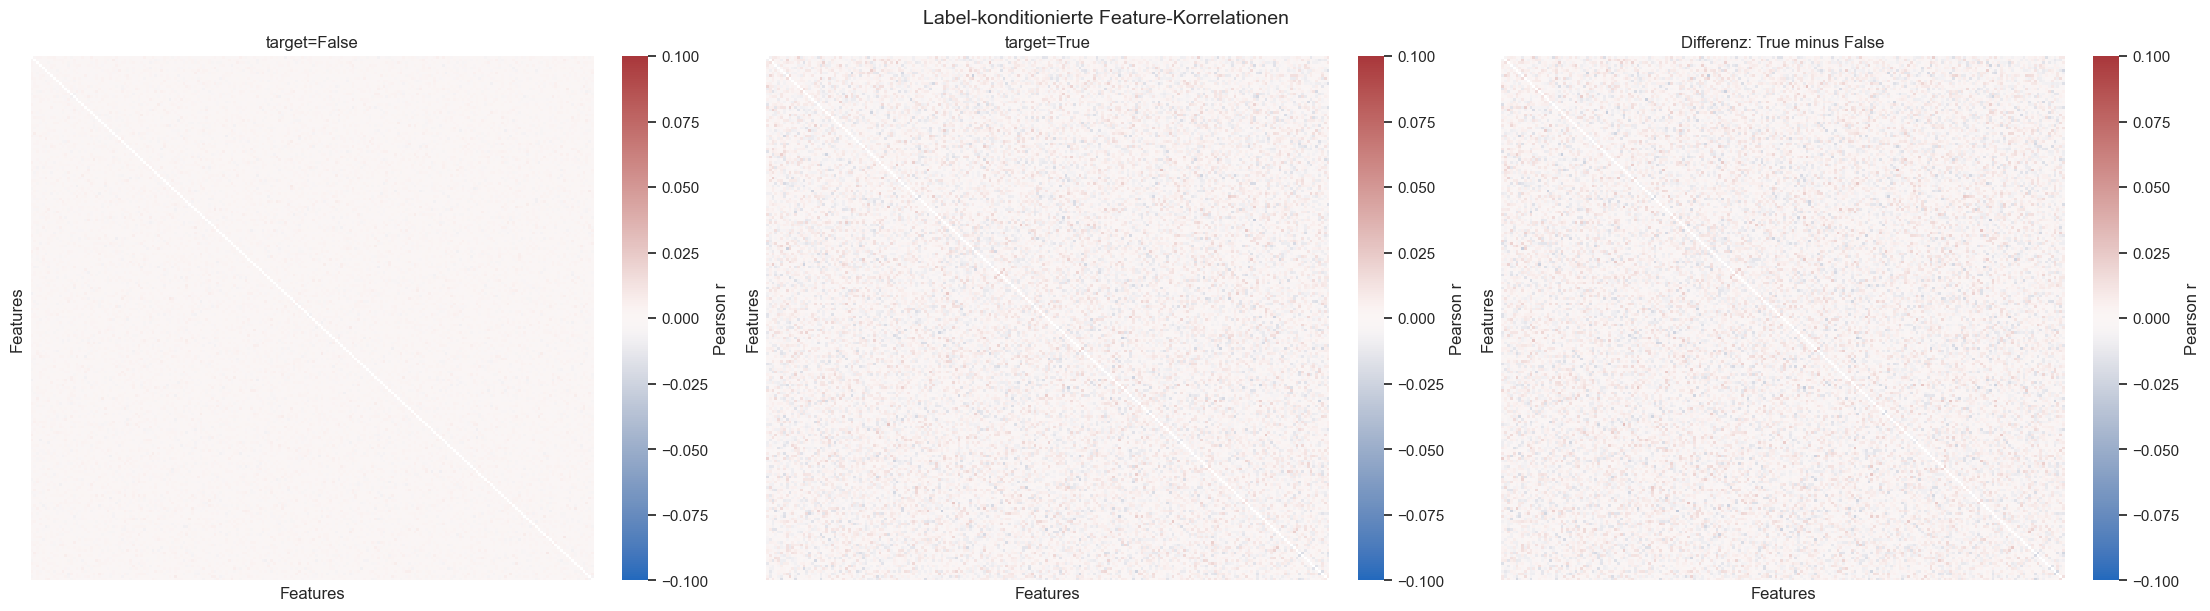

,,corr_false,corr_true,difference_true_minus_false,abs_difference
var_62,var_173,0.003212,-0.028243,-0.031455,0.031455
var_43,var_140,-0.002986,0.027719,0.030705,0.030705
var_107,var_126,0.001833,-0.027626,-0.029458,0.029458
var_66,var_170,-0.003426,0.025431,0.028857,0.028857
var_21,var_37,0.003912,-0.024065,-0.027977,0.027977
var_7,var_73,0.000489,-0.026928,-0.027417,0.027417
var_131,var_159,-0.003825,0.023268,0.027094,0.027094
var_125,var_149,-0.006273,0.020573,0.026846,0.026846
var_99,var_180,0.001692,-0.024822,-0.026513,0.026513
var_13,var_79,0.002107,-0.024288,-0.026395,0.026395


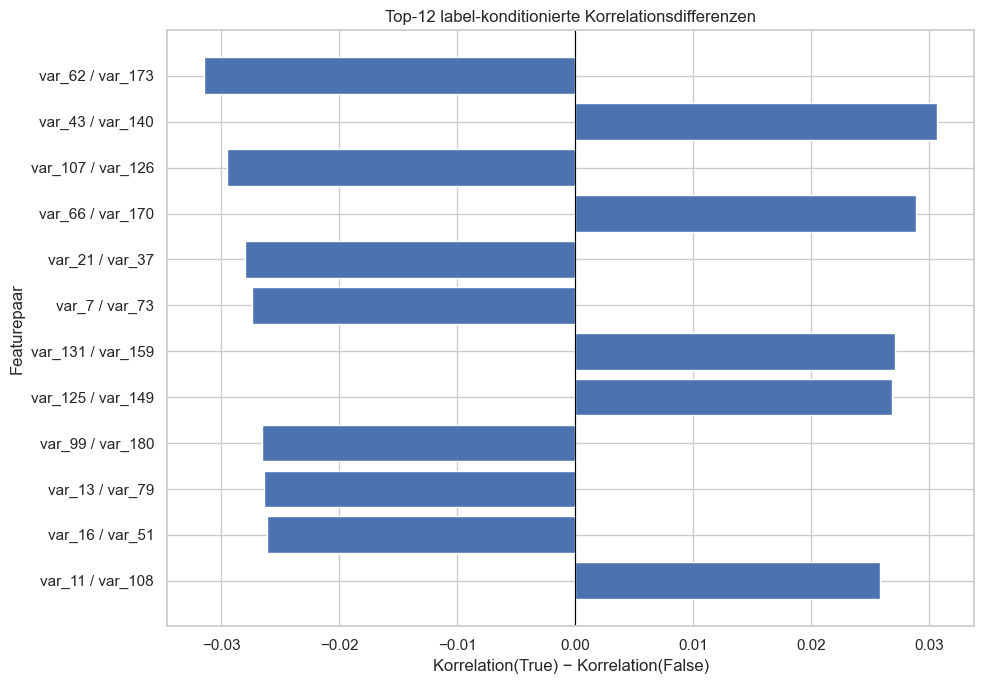

In [17]:
corr_false = X.loc[y == False].corr()
corr_true = X.loc[y == True].corr()
corr_difference = corr_true - corr_false

corr_false_plot = corr_false.mask(np.eye(corr_false.shape[0], dtype=bool))
corr_true_plot = corr_true.mask(np.eye(corr_true.shape[0], dtype=bool))
corr_difference_plot = corr_difference.mask(
    np.eye(corr_difference.shape[0], dtype=bool)
)

corr_common_limit = max(
    0.10,
    float(np.nanmax(np.abs(np.concatenate([
        corr_false_plot.to_numpy().ravel(),
        corr_true_plot.to_numpy().ravel(),
    ])))),
)
corr_diff_limit = max(
    0.10,
    float(np.nanmax(np.abs(corr_difference_plot.to_numpy()))),
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
specs = [
    (corr_false_plot, "target=False", corr_common_limit),
    (corr_true_plot, "target=True", corr_common_limit),
    (corr_difference_plot, "Differenz: True minus False", corr_diff_limit),
]
for ax, (matrix, title, limit) in zip(axes, specs):
    sns.heatmap(
        matrix,
        cmap="vlag",
        center=0,
        vmin=-limit,
        vmax=limit,
        xticklabels=False,
        yticklabels=False,
        ax=ax,
        cbar_kws={"label": "Pearson r"},
    )
    ax.set_title(title)
    ax.set_xlabel("Features")
    ax.set_ylabel("Features")

fig.suptitle("Label-konditionierte Feature-Korrelationen", fontsize=14)
fig.savefig(
    ASSET_PATH / "label_konditionierte_korrelationen.png",
    dpi=170,
    bbox_inches="tight",
)
plt.show()

upper_mask = np.triu(np.ones(corr_difference.shape), k=1).astype(bool)
corr_pair_comparison = pd.DataFrame({
    "corr_false": corr_false.where(upper_mask).stack(),
    "corr_true": corr_true.where(upper_mask).stack(),
})
corr_pair_comparison["difference_true_minus_false"] = (
    corr_pair_comparison["corr_true"] - corr_pair_comparison["corr_false"]
)
corr_pair_comparison["abs_difference"] = (
    corr_pair_comparison["difference_true_minus_false"].abs()
)
largest_corr_changes = corr_pair_comparison.sort_values(
    "abs_difference",
    ascending=False,
)

display(largest_corr_changes.head(25).round(6))

top_corr_pairs = largest_corr_changes.head(12).copy().reset_index()
top_corr_pairs["pair"] = (
    top_corr_pairs.iloc[:, 0].astype(str)
    + " / "
    + top_corr_pairs.iloc[:, 1].astype(str)
)
top_corr_pairs = top_corr_pairs.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_corr_pairs["pair"],
    top_corr_pairs["difference_true_minus_false"],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top-12 label-konditionierte Korrelationsdifferenzen")
ax.set_xlabel("Korrelation(True) − Korrelation(False)")
ax.set_ylabel("Featurepaar")
fig.tight_layout()
fig.savefig(
    ASSET_PATH / "top_korrelationsaenderungen.png",
    dpi=170,
    bbox_inches="tight",
)
plt.show()


### 4.4 1:1-Undersampling als **Sensitivitätsanalyse**, nicht als „fairere“ Hauptschätzung

Die getrennten Korrelationsmatrizen der vollständigen Klassen werden nicht durch die
größere False-Klasse gewichtet; sie besitzen lediglich unterschiedliche Schätzpräzision.
Deshalb bleiben die vollständigen Klassenmatrizen die Hauptanalyse.

Das 1:1-Undersampling dient ausschließlich dazu zu prüfen, wie stark sich die False-Korrelationen
ändern, wenn nur 20.098 negative Beobachtungen verwendet werden. Die True-Klasse bleibt dabei
unverändert.


Größte Änderungen durch das False-Undersampling:


,,corr_false_full,corr_true_full,difference_full,corr_false_1to1,corr_true_1to1,difference_1to1,difference_change_1to1_minus_full,abs_difference_change
var_121,var_151,-0.000010,0.006569,0.006579,0.029178,0.006569,-0.022609,-0.029188,0.029188
var_104,var_195,0.001093,-0.011497,-0.012590,-0.027332,-0.011497,0.015836,0.028426,0.028426
var_83,var_162,-0.000491,-0.010550,-0.010059,-0.026470,-0.010550,0.015920,0.025979,0.025979
var_23,var_93,0.003376,-0.000285,-0.003661,-0.022102,-0.000285,0.021816,0.025477,0.025477
var_99,var_160,-0.000109,-0.004347,-0.004238,-0.024455,-0.004347,0.020109,0.024347,0.024347
var_117,var_172,-0.001188,-0.000586,0.000601,0.022722,-0.000586,-0.023308,-0.023910,0.023910
var_35,var_77,0.001245,0.001743,0.000498,0.025109,0.001743,-0.023367,-0.023865,0.023865
var_90,var_91,-0.001470,0.002728,0.004198,0.022270,0.002728,-0.019541,-0.023739,0.023739
var_139,var_161,-0.001809,-0.003230,-0.001421,-0.025390,-0.003230,0.022159,0.023580,0.023580
var_19,var_134,-0.000562,-0.004943,-0.004380,-0.023843,-0.004943,0.018900,0.023281,0.023281


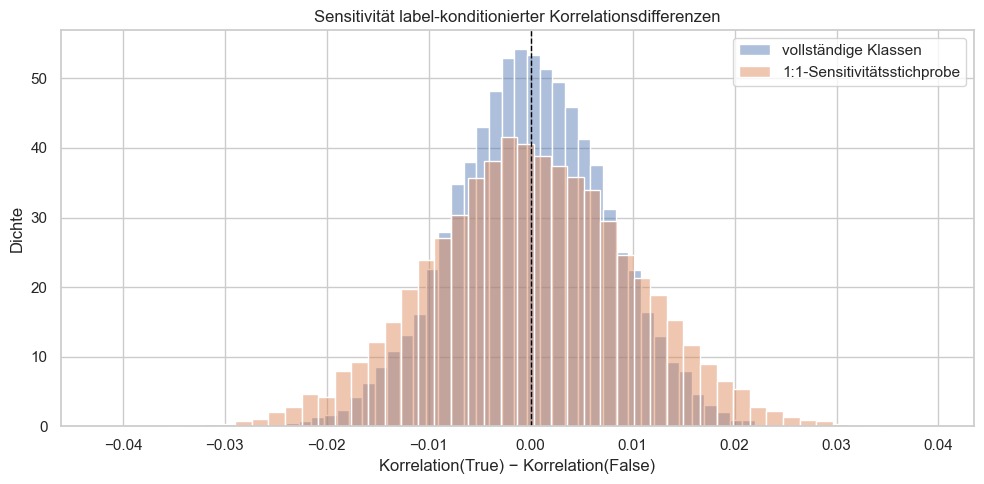

In [18]:
BALANCED_RANDOM_STATE = 42

balanced_false_indices = pd.Series(false_indices).sample(
    n=len(true_indices),
    random_state=BALANCED_RANDOM_STATE,
    replace=False,
).to_numpy()

corr_false_balanced = X.loc[balanced_false_indices].corr()
corr_true_balanced = X.loc[true_indices].corr()
corr_difference_balanced = corr_true_balanced - corr_false_balanced

baseline_pairs = pd.DataFrame({
    "corr_false_full": corr_false.where(upper_mask).stack(),
    "corr_true_full": corr_true.where(upper_mask).stack(),
})
baseline_pairs["difference_full"] = (
    baseline_pairs["corr_true_full"] - baseline_pairs["corr_false_full"]
)

balanced_pairs = pd.DataFrame({
    "corr_false_1to1": corr_false_balanced.where(upper_mask).stack(),
    "corr_true_1to1": corr_true_balanced.where(upper_mask).stack(),
})
balanced_pairs["difference_1to1"] = (
    balanced_pairs["corr_true_1to1"] - balanced_pairs["corr_false_1to1"]
)

comparison = baseline_pairs.join(balanced_pairs)
comparison["difference_change_1to1_minus_full"] = (
    comparison["difference_1to1"] - comparison["difference_full"]
)
comparison["abs_difference_change"] = (
    comparison["difference_change_1to1_minus_full"].abs()
)

print("Größte Änderungen durch das False-Undersampling:")
display(
    comparison.sort_values("abs_difference_change", ascending=False)
              .head(25)
              .round(6)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    comparison["difference_full"],
    stat="density",
    bins=50,
    alpha=0.45,
    label="vollständige Klassen",
    ax=ax,
)
sns.histplot(
    comparison["difference_1to1"],
    stat="density",
    bins=50,
    alpha=0.45,
    label="1:1-Sensitivitätsstichprobe",
    ax=ax,
)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Sensitivität label-konditionierter Korrelationsdifferenzen")
ax.set_xlabel("Korrelation(True) − Korrelation(False)")
ax.set_ylabel("Dichte")
ax.legend()
fig.tight_layout()
fig.savefig(
    ASSET_PATH / "corr_difference_full_vs_1to1.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


### 4.5 Stabilität und Bootstrap der Korrelationsbefunde

Die Korrelationsstärke wird über dieselbe Definition in allen Stichproben verglichen.
Zusätzlich werden für die fünf größten vollständigen Label-Differenzen Bootstrap-Intervalle
berechnet. Auch diese Intervalle sind aufgrund der vorherigen Top-Auswahl als
Sensitivitätsintervalle zu lesen.


In [19]:
def offdiag_abs_sum(matrix):
    return matrix.mask(np.eye(matrix.shape[0], dtype=bool)).abs().sum(axis=1)

def within_class_abs_corr_strength(false_idx, true_idx):
    cf = X.loc[false_idx].corr()
    ct = X.loc[true_idx].corr()
    return (offdiag_abs_sum(cf) + offdiag_abs_sum(ct)) / 2

rank_scores = {
    "full_within_class":
        (offdiag_abs_sum(corr_false) + offdiag_abs_sum(corr_true)) / 2
}
for seed in STABILITY_SEEDS:
    sampled_false_idx = pd.Series(false_indices).sample(
        n=len(true_indices),
        random_state=seed,
        replace=False,
    ).to_numpy()
    rank_scores[f"1to1_{seed}"] = within_class_abs_corr_strength(
        sampled_false_idx,
        true_indices,
    )

rank_scores = pd.DataFrame(rank_scores)
print("Spearman-Rangkorrelationen der Korrelationsstärken:")
display(rank_scores.rank(ascending=False).corr(method="spearman").round(4))

top_bootstrap_pairs = largest_corr_changes.head(5).index
pair_rows = []

for pair in top_bootstrap_pairs:
    a, b = pair
    values = []

    false_pair = X.loc[y == False, [a, b]].to_numpy()
    true_pair = X.loc[y == True, [a, b]].to_numpy()

    for _ in range(BOOTSTRAP_REPS):
        fi = rng_boot.integers(
            0, len(false_pair), size=BOOTSTRAP_SAMPLE_SIZE
        )
        ti = rng_boot.integers(
            0, len(true_pair), size=BOOTSTRAP_SAMPLE_SIZE
        )

        corr_f = np.corrcoef(false_pair[fi].T)[0, 1]
        corr_t = np.corrcoef(true_pair[ti].T)[0, 1]
        values.append(corr_t - corr_f)

    pair_rows.append([
        f"{a} / {b}",
        np.mean(values),
        np.percentile(values, 2.5),
        np.percentile(values, 97.5),
    ])

bootstrap_corr_ci = pd.DataFrame(
    pair_rows,
    columns=["pair", "difference_mean", "ci_2.5%", "ci_97.5%"],
).set_index("pair")

display(bootstrap_corr_ci.round(4))


Spearman-Rangkorrelationen der Korrelationsstärken:


,full_within_class,1to1_42,1to1_43,1to1_44,1to1_45,1to1_46
full_within_class,1.0000,0.7137,0.6630,0.6998,0.6615,0.6750
1to1_42,0.7137,1.0000,0.5113,0.4954,0.4779,0.5465
1to1_43,0.6630,0.5113,1.0000,0.4832,0.4440,0.4444
1to1_44,0.6998,0.4954,0.4832,1.0000,0.4909,0.5145
1to1_45,0.6615,0.4779,0.4440,0.4909,1.0000,0.5223
1to1_46,0.6750,0.5465,0.4444,0.5145,0.5223,1.0000


,difference_mean,ci_2.5%,ci_97.5%
pair,,,
var_62 / var_173,-0.0315,-0.0673,0.0038
var_43 / var_140,0.0308,-0.0069,0.0681
var_107 / var_126,-0.0305,-0.0672,0.0083
var_66 / var_170,0.0289,-0.0100,0.0690
var_21 / var_37,-0.0274,-0.0689,0.0137


## 5. Skalierung und Dimensionsreduktion

Alle Dimensionsreduktionsschritte stehen bewusst **an einer Stelle**. Zuerst wird geprüft,
wie skalenabhängig PCA ist; danach folgen PCA/t-SNE auf allen Features und abschließend der
bereits dokumentierte 14-Feature-Stress-Test als klar gekennzeichnete Nebenanalyse.

### 5.1 Skalierungsvergleich und PCA-Scree-Plot


,pc1,pc2,pc1_pc2_sum,pc1_pc20_sum
scaling,,,,
raw,0.071349,0.031022,0.102370,0.438968
standard,0.006113,0.005303,0.011416,0.106012
minmax,0.007503,0.006860,0.014363,0.129878
robust,0.006426,0.006170,0.012596,0.114452


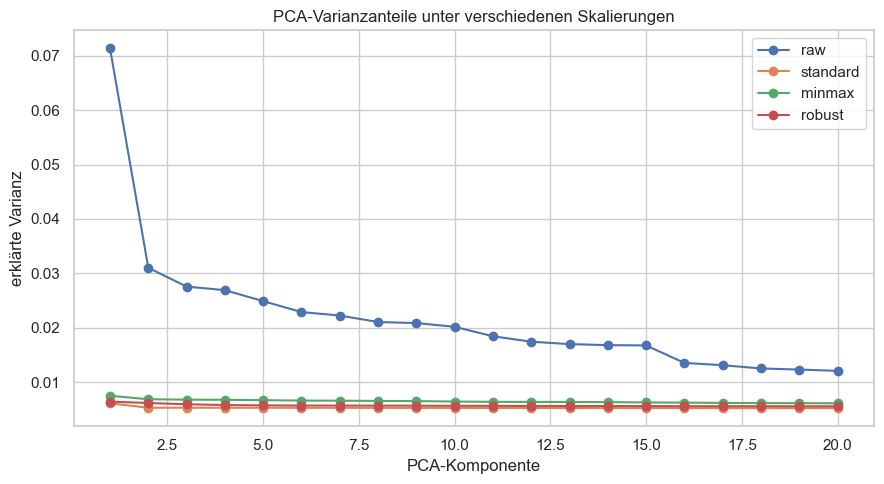

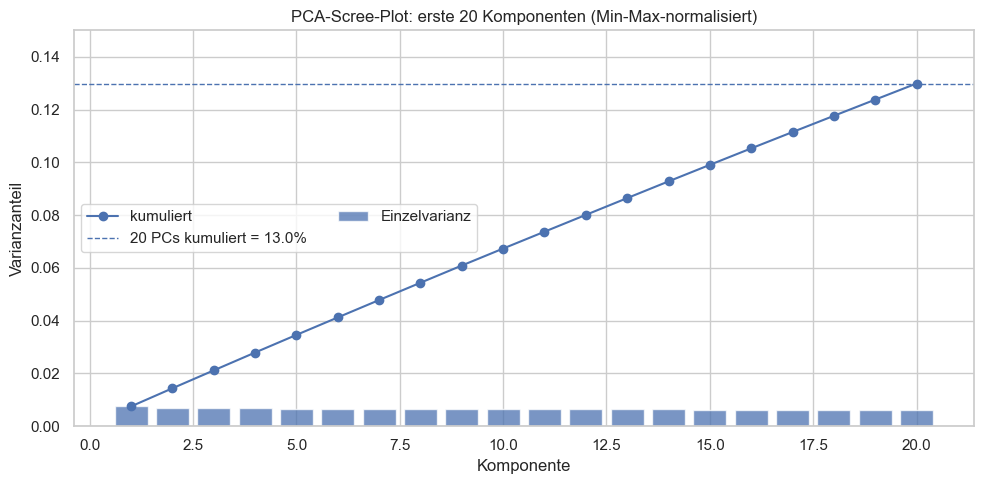

In [20]:
raw_matrix = X.to_numpy()
standard_matrix = StandardScaler().fit_transform(X)
minmax_matrix = X_minmax.to_numpy()
robust_matrix = RobustScaler().fit_transform(X)

rows = []
for name, matrix in [
    ("raw", raw_matrix),
    ("standard", standard_matrix),
    ("minmax", minmax_matrix),
    ("robust", robust_matrix),
]:
    model = PCA(n_components=20, random_state=RANDOM_STATE).fit(matrix)
    rows.append({
        "scaling": name,
        "pc1": model.explained_variance_ratio_[0],
        "pc2": model.explained_variance_ratio_[1],
        "pc1_pc2_sum": model.explained_variance_ratio_[:2].sum(),
        "pc1_pc20_sum": model.explained_variance_ratio_.sum(),
    })

scaling_pca_summary = pd.DataFrame(rows).set_index("scaling")
display(scaling_pca_summary.round(6))

fig, ax = plt.subplots(figsize=(9, 5))
for name, matrix in [
    ("raw", raw_matrix),
    ("standard", standard_matrix),
    ("minmax", minmax_matrix),
    ("robust", robust_matrix),
]:
    model = PCA(n_components=20, random_state=RANDOM_STATE).fit(matrix)
    ax.plot(
        range(1, 21),
        model.explained_variance_ratio_,
        marker="o",
        label=name,
    )
ax.set_title("PCA-Varianzanteile unter verschiedenen Skalierungen")
ax.set_xlabel("PCA-Komponente")
ax.set_ylabel("erklärte Varianz")
ax.legend()
fig.tight_layout()
fig.savefig(
    ASSET_PATH / "skalierungsvergleich_pca_varianz.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

pca_20 = PCA(n_components=20, random_state=RANDOM_STATE).fit(X_minmax)
explained_20 = pca_20.explained_variance_ratio_
cumulative_20 = explained_20.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 21), explained_20, alpha=0.75, label="Einzelvarianz")
ax.plot(range(1, 21), cumulative_20, marker="o", label="kumuliert")
ax.axhline(
    cumulative_20[-1],
    linestyle="--",
    linewidth=1,
    label=f"20 PCs kumuliert = {cumulative_20[-1]:.1%}",
)
ax.set_title("PCA-Scree-Plot: erste 20 Komponenten (Min-Max-normalisiert)")
ax.set_xlabel("Komponente")
ax.set_ylabel("Varianzanteil")
ax.set_ylim(0, max(0.15, float(cumulative_20[-1]) * 1.15))
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(
    ASSET_PATH / "pca_scree_kumulierte_varianz.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


### 5.2 PCA und t-SNE auf allen 200 Features

PCA wird auf der vollständigen Min-Max-Matrix berechnet. Diese Wahl ist keine allgemeine
PCA-Vorgabe, sondern eine dokumentierte EDA-Variante; Rohwerte, Standard-, Min-Max- und
robuste Skalierung werden zuvor separat verglichen. t-SNE nutzt aus Rechengründen eine
reproduzierbare 20.000er-Stichprobe und wird zuvor auf 50 PCA-Komponenten reduziert.
`target` ist nie Eingabefeature, sondern dient nur zur nachträglichen Visualisierung.


PCA erklärte Varianz (2 Komponenten): [0.007503 0.00686 ]
t-SNE-Matrix: (20000, 2)


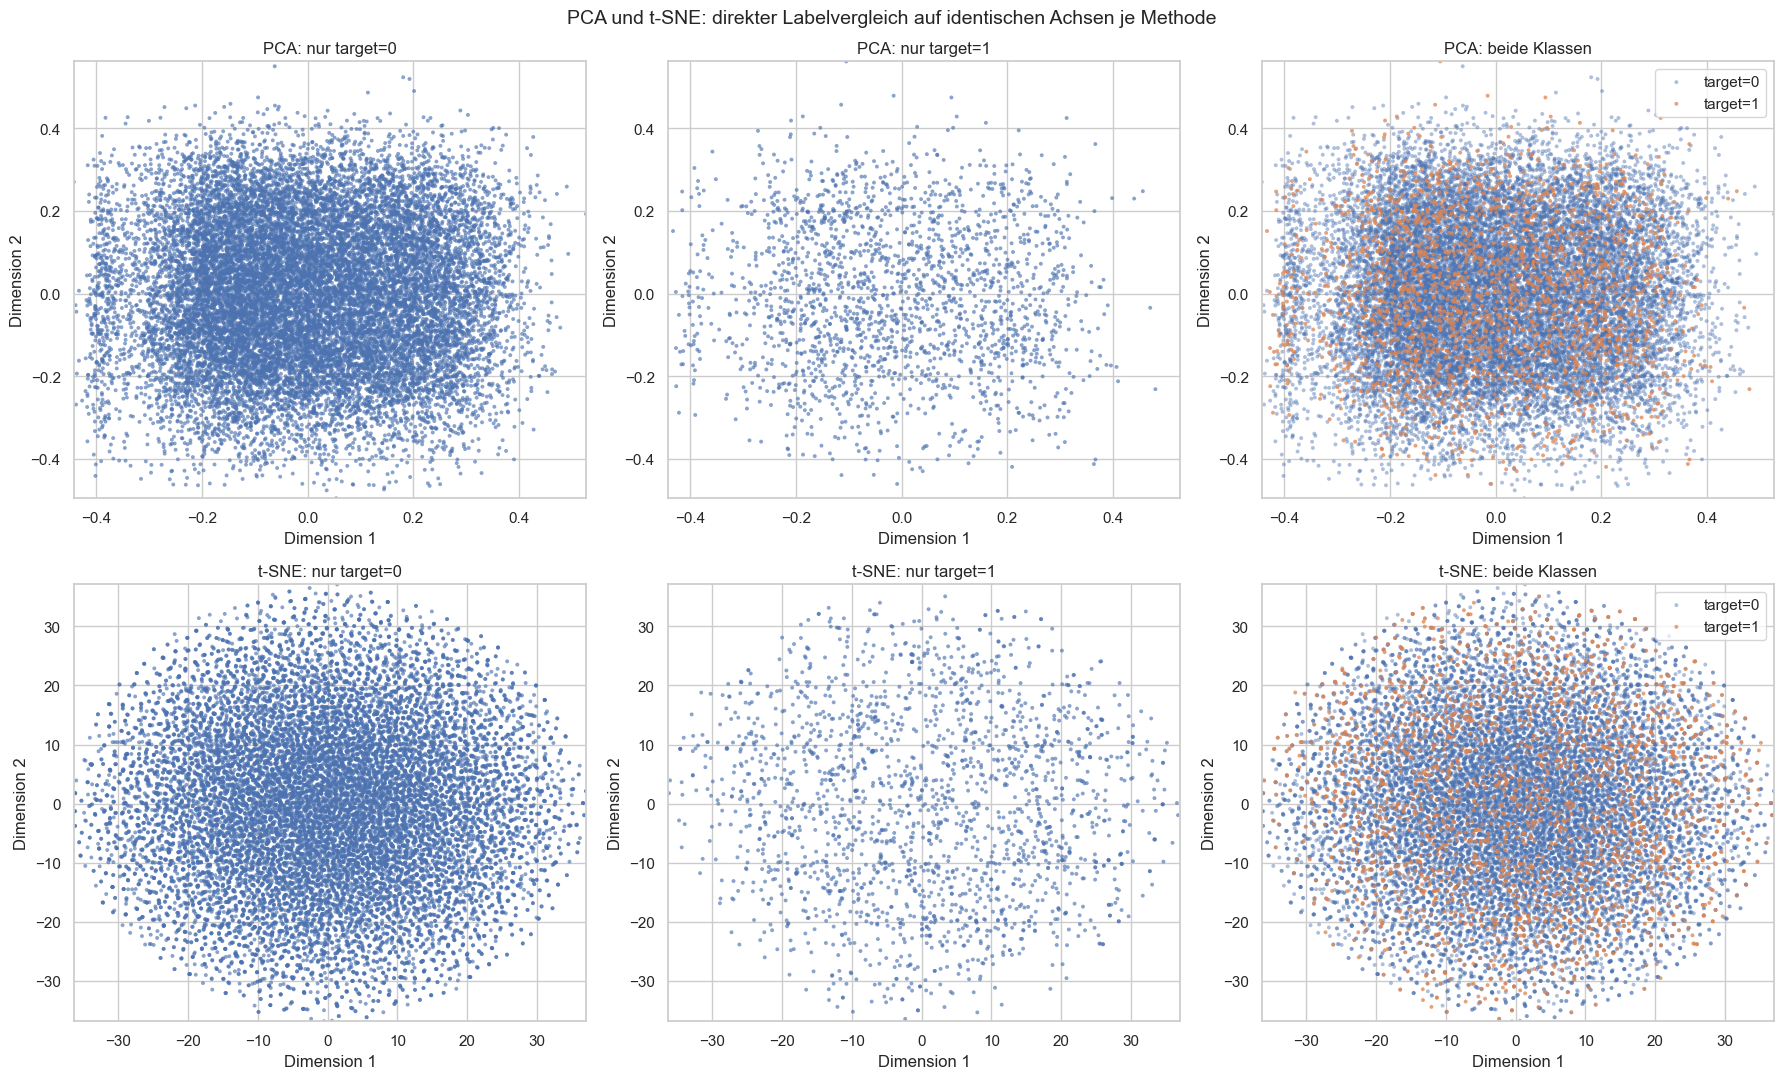

In [21]:
# Min-Max bleibt hier die dokumentierte EDA-Darstellung. Der vorherige
# Skalierungsvergleich zeigt separat, wie stark die PCA-Varianzanteile
# von Rohwerten, Standard-, Min-Max- und robuster Skalierung abhängen.
EMBED_SAMPLE_SIZE = 20000
embed_indices = df.sample(
    n=EMBED_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
).index

X_embed = X_minmax.loc[embed_indices]
y_embed = y.loc[embed_indices].astype(int).to_numpy()

pca_2d_model = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d_all = pca_2d_model.fit_transform(X_minmax)
pca_2d_df = pd.DataFrame(
    pca_2d_all,
    index=X_minmax.index,
    columns=["PC1", "PC2"],
)
pca_sample_2d = pca_2d_df.loc[embed_indices].to_numpy()

pca_50_model = PCA(n_components=50, random_state=RANDOM_STATE)
X_embed_pca50 = pca_50_model.fit_transform(X_embed)

tsne_2d_model = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=750,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
tsne_2d = tsne_2d_model.fit_transform(X_embed_pca50)

print("PCA erklärte Varianz (2 Komponenten):",
      pca_2d_model.explained_variance_ratio_.round(6))
print("t-SNE-Matrix:", tsne_2d.shape)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for row, (method_name, embedding) in enumerate([
    ("PCA", pca_sample_2d),
    ("t-SNE", tsne_2d),
]):
    limits_x = (embedding[:, 0].min(), embedding[:, 0].max())
    limits_y = (embedding[:, 1].min(), embedding[:, 1].max())

    for col, label_value in enumerate([0, 1]):
        mask = y_embed == label_value
        axes[row, col].scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=8,
            alpha=0.65,
            edgecolors="none",
        )
        axes[row, col].set_xlim(limits_x)
        axes[row, col].set_ylim(limits_y)
        axes[row, col].set_title(
            f"{method_name}: nur target={label_value}"
        )

    axes[row, 2].scatter(
        embedding[y_embed == 0, 0],
        embedding[y_embed == 0, 1],
        s=8,
        alpha=0.45,
        label="target=0",
        edgecolors="none",
    )
    axes[row, 2].scatter(
        embedding[y_embed == 1, 0],
        embedding[y_embed == 1, 1],
        s=8,
        alpha=0.75,
        label="target=1",
        edgecolors="none",
    )
    axes[row, 2].set_xlim(limits_x)
    axes[row, 2].set_ylim(limits_y)
    axes[row, 2].set_title(f"{method_name}: beide Klassen")
    axes[row, 2].legend()

    for col in range(3):
        axes[row, col].set_xlabel("Dimension 1")
        axes[row, col].set_ylabel("Dimension 2")

fig.suptitle(
    "PCA und t-SNE: direkter Labelvergleich auf identischen Achsen je Methode",
    fontsize=14,
)
fig.tight_layout()
fig.savefig(
    ASSET_PATH / "pca_tsne_target_comparison.png",
    dpi=170,
    bbox_inches="tight",
)
plt.show()


### 5.3 K-Means und DBSCAN als unüberwachte Zusatzdiagnostik

Die Clusteranalyse ist bewusst nachgeordnet. `k=2` orientiert sich an der Anzahl der
Zielklassen und ist daher kein unabhängiger Nachweis einer natürlichen Clusterzahl.
DBSCAN wird nur mit einer dokumentierten Startparametrisierung betrachtet; ein schwaches
Ergebnis ist ohne systematische Parametersuche kein Beweis gegen Clusterstruktur.
ARI und NMI vergleichen die Cluster **erst nachträglich** mit `target`.


PCA-Embedding


,Wert
K-Means ARI,-0.0007
K-Means NMI,0.0001
DBSCAN ARI,0.0008
DBSCAN NMI,0.0007


t-SNE-Embedding


,Wert
K-Means ARI,-0.0002
K-Means NMI,0.0002
DBSCAN ARI,0.0000
DBSCAN NMI,0.0000


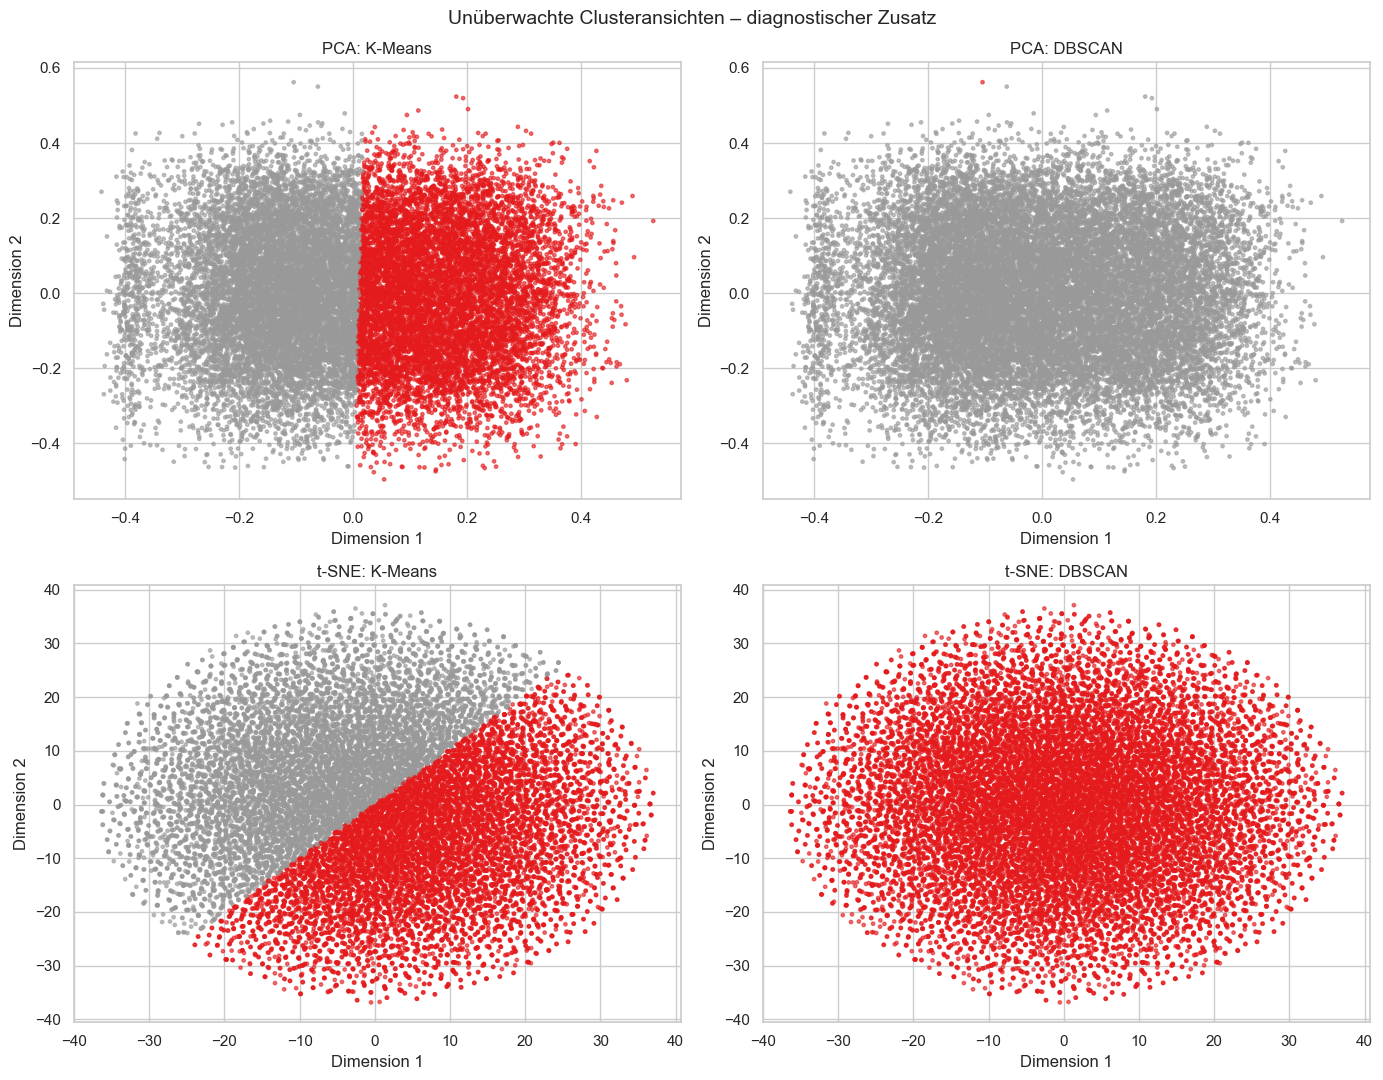

In [22]:
def cluster_embedding(embedding, name, eps=0.5):
    scaled_embedding = StandardScaler().fit_transform(embedding)

    kmeans_labels = KMeans(
        n_clusters=2,
        random_state=RANDOM_STATE,
        n_init=10,
    ).fit_predict(scaled_embedding)

    dbscan_labels = DBSCAN(
        eps=eps,
        min_samples=10,
        n_jobs=-1,
    ).fit_predict(scaled_embedding)

    metrics = {
        "K-Means ARI": adjusted_rand_score(y_embed, kmeans_labels),
        "K-Means NMI": normalized_mutual_info_score(y_embed, kmeans_labels),
        "DBSCAN ARI": adjusted_rand_score(y_embed, dbscan_labels),
        "DBSCAN NMI": normalized_mutual_info_score(y_embed, dbscan_labels),
    }
    print(name)
    display(pd.Series(metrics).to_frame("Wert").round(4))

    return kmeans_labels, dbscan_labels

pca_kmeans, pca_dbscan = cluster_embedding(
    pca_sample_2d,
    "PCA-Embedding",
    eps=0.5,
)
tsne_kmeans, tsne_dbscan = cluster_embedding(
    tsne_2d,
    "t-SNE-Embedding",
    eps=0.5,
)

plot_specs = [
    (pca_sample_2d, pca_kmeans, "PCA: K-Means"),
    (pca_sample_2d, pca_dbscan, "PCA: DBSCAN"),
    (tsne_2d, tsne_kmeans, "t-SNE: K-Means"),
    (tsne_2d, tsne_dbscan, "t-SNE: DBSCAN"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (embedding, labels, title) in zip(axes.flat, plot_specs):
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        s=6,
        alpha=0.6,
        cmap="Set1",
    )
    ax.set_title(title)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

fig.suptitle("Unüberwachte Clusteransichten – diagnostischer Zusatz", fontsize=14)
fig.tight_layout()
fig.savefig(
    ASSET_PATH / "pca_tsne_clustering_overview.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


### 5.4 Korrelationsbasierter 14-Feature-Stress-Test

Dieser bereits dokumentierte Versuch wird nicht als finale Featureselektion verkauft.
Die Auswahl ist label-informiert und heuristisch: sieben Features mit den größten positiven
und sieben mit den größten negativen **signierten** Summen der
label-konditionierten Korrelationsänderungen. Die Zahl 14 ist eine kompakte
Explorationsgröße, keine statistisch hergeleitete optimale Featurezahl.

Der Versuch beantwortet nur die Frage, ob eine gezielt anders zusammengesetzte Teilmenge die
2D-Projektion sichtbar verändert. Für spätere Modellselektion müsste eine solche Auswahl
innerhalb der Trainings-Folds gelernt werden.


,signed_corr_change_score
var_161,0.349770
var_188,0.297482
var_177,0.209690
var_123,0.208473
var_84,0.193782
var_63,0.193403
var_7,0.188635
var_169,-0.197338
var_69,-0.203457
var_194,-0.204869


PCA erklärte Gesamtvarianz der ersten zwei Komponenten: 0.171223


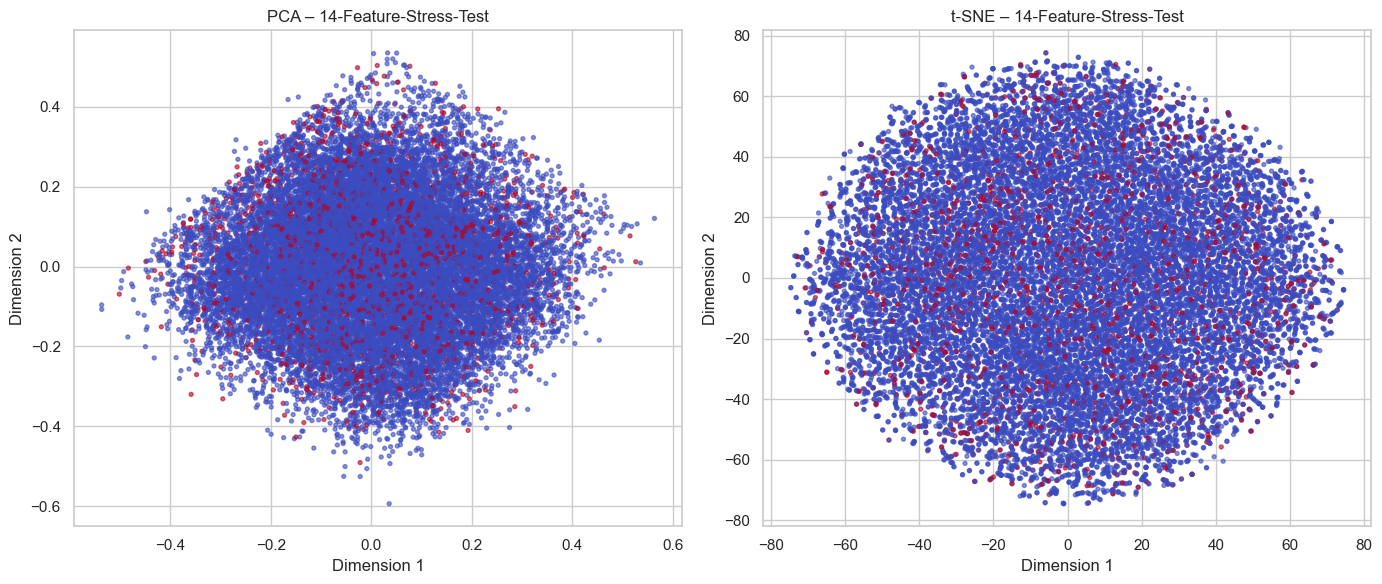

In [23]:
corr_difference_offdiag = corr_difference.mask(
    np.eye(corr_difference.shape[0], dtype=bool)
)
signed_corr_change_score = corr_difference_offdiag.sum(axis=1)

positive_selected_features = (
    signed_corr_change_score.nlargest(7).index.tolist()
)
negative_selected_features = (
    signed_corr_change_score.nsmallest(7).index.tolist()
)
selected_features = positive_selected_features + negative_selected_features

display(
    signed_corr_change_score.loc[selected_features]
    .sort_values(ascending=False)
    .rename("signed_corr_change_score")
    .to_frame()
    .round(6)
)

X_selected = X_minmax[selected_features]

pca_selected_model = PCA(n_components=2, random_state=RANDOM_STATE)
pca_selected_all = pca_selected_model.fit_transform(X_selected)
pca_selected_df = pd.DataFrame(
    pca_selected_all,
    index=X_selected.index,
    columns=["PC1", "PC2"],
)
pca_selected_sample = pca_selected_df.loc[embed_indices].to_numpy()

pca_selected_for_tsne = PCA(
    n_components=min(14, len(selected_features)),
    random_state=RANDOM_STATE,
)
X_selected_embed_pca = pca_selected_for_tsne.fit_transform(
    X_selected.loc[embed_indices]
)

tsne_selected = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=750,
    random_state=RANDOM_STATE,
    n_jobs=-1,
).fit_transform(X_selected_embed_pca)

print(
    "PCA erklärte Gesamtvarianz der ersten zwei Komponenten:",
    round(pca_selected_model.explained_variance_ratio_.sum(), 6),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (embedding, title) in zip(
    axes,
    [
        (pca_selected_sample, "PCA – 14-Feature-Stress-Test"),
        (tsne_selected, "t-SNE – 14-Feature-Stress-Test"),
    ],
):
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_embed,
        s=8,
        alpha=0.6,
        cmap="coolwarm",
    )
    ax.set_title(title)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

fig.tight_layout()
fig.savefig(
    ASSET_PATH / "selected_features_dimension_reduction.png",
    dpi=170,
    bbox_inches="tight",
)
plt.show()


## 6. Überwachte Referenz: train-test-getrennte Logistic Regression

Die Baseline dient **nicht** als finales Modell, sondern als Plausibilitätscheck:
Kann trotz schwacher 2D-Trennung prädiktive Information vorhanden sein?

Wichtig ist die Reihenfolge: Zuerst werden die Rohfeatures gesplittet. Der MinMaxScaler wird
innerhalb einer Pipeline ausschließlich auf `X_train` gefittet. ROC-AUC und Average Precision
(AP) sind schwellenunabhängig; Balanced Accuracy, Recall, Precision und F1 werden zusätzlich
für den noch nicht optimierten Schwellenwert 0,5 berichtet. Die Transformation ist damit
innerhalb dieser Referenz leakage-frei. Da derselbe 80:20-Split später in der ML-Pipeline
wiederverwendet wurde, ist deren Hold-out jedoch nicht gegenüber der gesamten EDA unberührt;
die spätere Testauswertung ist deshalb als interne explorative Schätzung einzuordnen.


,Wert
ROC-AUC,0.859897
Average Precision (AP),0.500414
Balanced Accuracy @ 0.5,0.779752
Recall @ 0.5,0.775373
Precision @ 0.5,0.286384
F1 @ 0.5,0.418277


Positivanteil im Testset (AP-Nullreferenz): 0.100500


,pred 0,pred 1
true 0,28213,7767
true 1,903,3117


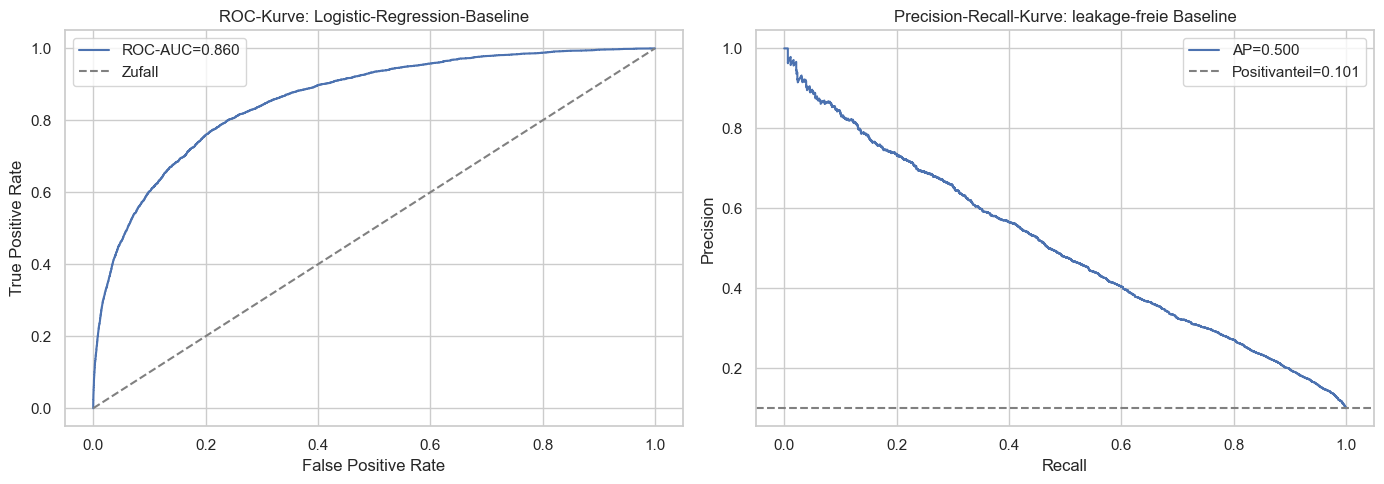

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.astype(int),
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

baseline_model = Pipeline([
    ("scaler", MinMaxScaler()),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs",
        ),
    ),
])

baseline_model.fit(X_train, y_train)
baseline_probability = baseline_model.predict_proba(X_test)[:, 1]

BASELINE_THRESHOLD = 0.5
baseline_prediction = (
    baseline_probability >= BASELINE_THRESHOLD
).astype(int)

baseline_metrics = pd.Series({
    "ROC-AUC": roc_auc_score(y_test, baseline_probability),
    "Average Precision (AP)": average_precision_score(
        y_test,
        baseline_probability,
    ),
    "Balanced Accuracy @ 0.5": balanced_accuracy_score(
        y_test,
        baseline_prediction,
    ),
    "Recall @ 0.5": recall_score(y_test, baseline_prediction),
    "Precision @ 0.5": precision_score(y_test, baseline_prediction),
    "F1 @ 0.5": f1_score(y_test, baseline_prediction),
})
display(baseline_metrics.to_frame("Wert").round(6))

print(f"Positivanteil im Testset (AP-Nullreferenz): {y_test.mean():.6f}")
display(
    pd.DataFrame(
        confusion_matrix(y_test, baseline_prediction),
        index=["true 0", "true 1"],
        columns=["pred 0", "pred 1"],
    )
)

roc_fpr, roc_tpr, _ = roc_curve(y_test, baseline_probability)
pr_precision, pr_recall, _ = precision_recall_curve(
    y_test,
    baseline_probability,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(
    roc_fpr,
    roc_tpr,
    label=f"ROC-AUC={baseline_metrics['ROC-AUC']:.3f}",
)
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Zufall")
axes[0].set_title("ROC-Kurve: Logistic-Regression-Baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(
    pr_recall,
    pr_precision,
    label=f"AP={baseline_metrics['Average Precision (AP)']:.3f}",
)
axes[1].axhline(
    y_test.mean(),
    linestyle="--",
    color="grey",
    label=f"Positivanteil={y_test.mean():.3f}",
)
axes[1].set_title("Precision-Recall-Kurve: leakage-freie Baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

fig.tight_layout()
fig.savefig(
    ASSET_PATH / "baseline_logistic_roc_pr.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## 7. Gesamtauswertung und Schlussfolgerung

Die Schlussfolgerung wird bewusst **nicht chronologisch**, sondern nach Aussagekraft geordnet.
Die direkt davor berechnete Ergebnistabelle hält die wichtigsten Kennzahlen automatisch
synchron mit dem tatsächlich ausgeführten Notebook.


In [25]:
key_results = pd.Series({
    "Beobachtungen": len(df),
    "Features": len(feature_columns),
    "Positivanteil target=True": float(y.mean()),
    "Fehlende Zellen": int(df.isna().sum().sum()),
    "Max. |Cohen's d|": float(feature_comparison["abs_cohens_d"].max()),
    "FDR-signifikante Features (alpha=0.05)":
        int(multiple_testing["significant_fdr_0.05"].sum()),
    "Featurepaare mit |r| >= 0.8": int(len(redundancy_pairs)),
    "Kumulative PCA-Varianz, erste 20 PCs":
        float(cumulative_20[-1]),
    "Baseline ROC-AUC": float(baseline_metrics["ROC-AUC"]),
    "Baseline Average Precision":
        float(baseline_metrics["Average Precision (AP)"]),
    "Baseline Balanced Accuracy @ 0.5":
        float(baseline_metrics["Balanced Accuracy @ 0.5"]),
    "Baseline Precision @ 0.5":
        float(baseline_metrics["Precision @ 0.5"]),
    "Baseline Recall @ 0.5":
        float(baseline_metrics["Recall @ 0.5"]),
})
display(key_results.to_frame("Wert").round(6))


,Wert
Beobachtungen,200000.000000
Features,200.000000
Positivanteil target=True,0.100490
Fehlende Zellen,0.000000
Max. |Cohen's d|,0.270023
FDR-signifikante Features (alpha=0.05),181.000000
Featurepaare mit |r| >= 0.8,0.000000
"Kumulative PCA-Varianz, erste 20 PCs",0.129878
Baseline ROC-AUC,0.859897
Baseline Average Precision,0.500414


### 7.1 Belastbare Befunde

- Der Datensatz ist technisch sauber genug für die weitere Modellierung: Missing Values und
  nicht-finite Werte werden explizit geprüft, ebenso Duplikate und konstante Features.
- Die Zielvariable ist stark unausgeglichen. Deshalb sind Accuracy und eine alleinige
  Betrachtung des Schwellenwerts 0,5 nicht ausreichend.
- Viele Features können wegen der großen Stichprobe statistisch signifikante Gruppenunterschiede
  zeigen. **Praktische Relevanz wird deshalb primär über Effektgrößen und deren Stabilität
  eingeordnet, nicht über p-Werte allein.**
- Starke lineare Redundanz wird mit dem gewählten Schwellenwert $|r|\geq0{,}8$ nicht festgestellt.
  Das schließt schwächere oder nichtlineare Redundanz nicht aus.

### 7.2 Explorative Befunde

- Mutual Information ergänzt die lineare Sicht, bleibt aber ein univariates Ranking.
- Label-konditionierte Korrelationsdifferenzen werden mit vollständigen Klassen als Hauptanalyse
  betrachtet. Das 1:1-Undersampling ist lediglich eine Sensitivitätsprüfung und keine
  methodisch „fairere“ Schätzung.
- PCA und t-SNE zeigen keine klare 2D-Trennung. Das ist wegen der geringen von wenigen
  PCA-Komponenten erfassten Gesamtvarianz und der lokalen Natur von t-SNE **kein Beweis gegen
  Vorhersagbarkeit**.
- K-Means/DBSCAN und der 14-Feature-Stress-Test sind Nebenanalysen. Sie dürfen nicht die
  Hauptargumentation dominieren und stellen keine finale Featureselektion dar.

### 7.3 Brücke zur Modellierung

Die leakage-freie Logistic Regression zeigt, ob die 200 Features trotz schwacher visueller
Trennung prädiktive Information tragen. Für die stark unausgeglichene Zielvariable sind
ROC-AUC und insbesondere **Average Precision** zentrale schwellenunabhängige Referenzen.
Precision, Recall, F1 und Balanced Accuracy bei 0,5 sind nur ein vorläufiger Betriebspunkt.

### 7.4 Konsequenz

Der nächste Schritt ist eine reproduzierbare Cross-Validation mit vollständig leakage-freien
Pipelines. Skalierung, label-informierte Featureselektion und Hyperparameteroptimierung müssen
innerhalb der Trainings-Folds erfolgen. Modellranking und spätere Schwellenwertwahl sollten
getrennt behandelt werden.
